# Hostel Electricity Consumption Analyzer
### An End-to-End Statistical and Business Intelligence Analysis

---

## 1. Business Problem

Hostels house hundreds of students across multiple blocks and room types, each drawing electricity independently through room-level meters. Without systematic analysis, institutions cannot tell **which rooms, blocks, or hostels consume disproportionately more electricity**, whether that consumption is justified by occupancy, or where faulty meters and inconsistent billing are quietly costing money.

This project analyzes historical room-level electricity meter readings to understand **how much electricity is consumed, where it is concentrated, whether it aligns with occupancy, and what operational/billing issues exist**, so hostel administration can make evidence-based energy-management decisions.

## 2. Business Objectives

- Quantify total electricity consumption and cost across hostels, blocks, and room types.
- Determine whether consumption scales sensibly with occupancy, or whether some rooms are disproportionately heavy consumers.
- Identify meter/billing data-quality issues (faulty meters, inconsistent cost calculations, impossible readings).
- Detect time-based patterns (day-of-week, monthly, trend across the observed period, peak vs off-peak usage).
- Segment rooms/records into consumption-risk categories to prioritize energy-efficiency action.
- Translate all findings into actionable, prioritized recommendations for hostel management.

## 3. Business Questions

1. What does a "typical" room's electricity consumption look like?
2. How variable is consumption — is it consistent or unpredictable across rooms?
3. Is consumption concentrated in a small number of rooms/hostels (Pareto effect)?
4. Does consumption scale sensibly with occupancy, or are some low-occupancy rooms consuming heavily?
5. Are there time-based patterns (month, trend, peak vs off-peak)?
6. What conditions are associated with unusually high consumption or cost?
7. What operational thresholds should trigger a maintenance/energy-audit review?
8. What should hostel management prioritize to reduce electricity cost and waste?

## 4. Technology Used

This notebook uses **only** `pandas`, `numpy`, `matplotlib`, and `seaborn`. No machine-learning or external statistical libraries (`scipy`, `sklearn`, `statsmodels`, etc.) are used. Wherever a technique would normally rely on one of those libraries, the underlying calculation is implemented directly with `pandas`/`numpy`, and any resulting limitation is explicitly stated.

## 5. Dataset

The dataset used is the actual hostel electricity meter-reading log previously generated for this project (`Hostel_Electricity_Consumption_Analyzer.xlsx`). It is intentionally messy (missing values, inconsistent text, mixed data types, illogical meter readings, duplicates) and also intentionally contains several **hostel-related but analytically unuseful columns** (e.g., Warden_Name, WiFi_Available, Mess_Timing, Building_Color, Hostel_Contact_Number, Remarks) that must be identified and removed during cleaning — reflecting a realistic raw institutional export. **No values, rows, or results in this notebook are fabricated; every number is computed from this dataset.**


In [8]:
%pip install matplotlib
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 6. Setup

We import the four permitted libraries and configure display/plotting defaults for consistent, readable output throughout the notebook.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10


## 7. Load the Dataset

We load the raw Excel file exactly as exported, with no pre-cleaning, so the data-quality assessment reflects the true state of the raw data.

In [10]:
raw_df = pd.read_excel("Hostel_Electricity_Consumption_Analyzer.xlsx")
print("Raw dataset shape:", raw_df.shape)
raw_df.head(10)


ImportError: `Import openpyxl` failed.  Use pip or conda to install the openpyxl package.

## 8. Dataset Understanding

### What are we trying to understand?
Before any cleaning or analysis, we need to know exactly what columns exist, what they represent, and which ones are actually useful for an electricity-consumption analysis versus which are administrative clutter carried over from the hostel's general records system.

In [ ]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2560 entries, 0 to 2559
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Record_ID                 2548 non-null   str    
 1   Reading_Date              2496 non-null   str    
 2   Hostel_Name               2555 non-null   str    
 3   Hostel_Code               2555 non-null   str    
 4   Block                     2220 non-null   str    
 5   Floor                     2087 non-null   float64
 6   Room_Number               2555 non-null   str    
 7   Room_Type                 2042 non-null   str    
 8   Occupancy_Count           2336 non-null   object 
 9   Room_Capacity             2555 non-null   float64
 10  Student_Type              2240 non-null   str    
 11  Meter_ID                  2555 non-null   str    
 12  Previous_Reading_kWh      2410 non-null   float64
 13  Current_Reading_kWh       2403 non-null   float64
 14  Units_Consumed_kWh 

### Data Dictionary

The table below documents every column in the raw dataset, its meaning, and — critically — whether it is analytically **useful** for this project or **not useful** (to be dropped during cleaning). Marking this upfront makes the later column-removal decision transparent and auditable rather than arbitrary.

In [ ]:
data_dictionary = pd.DataFrame([
    ("Record_ID",                "Unique identifier for each meter-reading record",              "Useful"),
    ("Reading_Date",              "Date the meter reading was taken",                              "Useful"),
    ("Hostel_Name",               "Name of the hostel",                                            "Useful"),
    ("Hostel_Code",               "Short code for the hostel",                                     "Useful"),
    ("Block",                     "Block within the hostel",                                       "Useful"),
    ("Floor",                     "Floor number of the room",                                      "Useful"),
    ("Room_Number",               "Specific room identifier",                                      "Useful"),
    ("Room_Type",                 "Single / Double / Triple / Dormitory",                          "Useful"),
    ("Occupancy_Count",           "Number of students currently occupying the room",               "Useful"),
    ("Room_Capacity",             "Maximum students the room is designed for",                     "Useful"),
    ("Student_Type",              "UG / PG / PhD / Research Scholar",                              "Useful"),
    ("Meter_ID",                  "Unique electricity meter identifier for the room",              "Useful"),
    ("Previous_Reading_kWh",      "Meter reading at the start of the billing period",              "Useful"),
    ("Current_Reading_kWh",       "Meter reading at the end of the billing period",                "Useful"),
    ("Units_Consumed_kWh",        "Electricity units consumed (Current - Previous)",               "Useful"),
    ("Electricity_Rate_Per_kWh",  "Tariff rate applied",                                           "Useful"),
    ("Electricity_Cost",          "Total cost billed for the period",                              "Useful"),
    ("Peak_or_OffPeak",           "Whether the reading falls in peak or off-peak tariff window",   "Useful"),
    ("Appliance_Details",         "Appliances reported in the room",                               "Useful"),
    ("Reading_Status",            "Normal / Estimated / Disputed / Pending Verification",          "Useful"),
    ("Maintenance_Status",        "Status of the meter/room electrical setup",                     "Useful"),
    ("Recorded_By",               "Person/system that recorded the reading",                       "Useful"),
    ("Warden_Name",               "Name of the hostel warden",                                     "NOT Useful - administrative, unrelated to consumption"),
    ("WiFi_Available",            "Whether the room has WiFi",                                     "NOT Useful - amenity info, not electricity-related"),
    ("Mess_Timing",               "Meal timings for the hostel mess",                              "NOT Useful - food service info, unrelated"),
    ("Building_Color",            "Exterior paint color of the building",                          "NOT Useful - cosmetic detail, no analytical value"),
    ("Hostel_Contact_Number",     "Administrative contact number",                                 "NOT Useful - contact info, not electricity-related"),
    ("Remarks",                   "Free-text notes",                                               "NOT Useful - unstructured, inconsistent free text"),
], columns=["Column", "Description", "Analytical Relevance"])

data_dictionary


,Column,Description,Analytical Relevance
0,Record_ID,Unique identifier for each meter-reading record,Useful
1,Reading_Date,Date the meter reading was taken,Useful
2,Hostel_Name,Name of the hostel,Useful
3,Hostel_Code,Short code for the hostel,Useful
4,Block,Block within the hostel,Useful
5,Floor,Floor number of the room,Useful
6,Room_Number,Specific room identifier,Useful
7,Room_Type,Single / Double / Triple / Dormitory,Useful
8,Occupancy_Count,Number of students currently occupying the room,Useful
9,Room_Capacity,Maximum students the room is designed for,Useful


## 9. Data Quality Assessment

### What are we trying to understand?
Before trusting any statistic, we quantify: missing values, duplicate records, inconsistent text formatting, mixed data types inside numeric columns, and logically impossible meter/occupancy values.

In [ ]:
missing_count = raw_df.isna().sum()
missing_pct = (missing_count / len(raw_df) * 100).round(2)
dq_missing = pd.DataFrame({'Missing_Count': missing_count, 'Missing_Pct': missing_pct})
dq_missing = dq_missing[dq_missing['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False)
dq_missing


,Missing_Count,Missing_Pct
Mess_Timing,868,33.91
Remarks,838,32.73
Warden_Name,566,22.11
Room_Type,518,20.23
WiFi_Available,517,20.20
Appliance_Details,512,20.00
Peak_or_OffPeak,497,19.41
Building_Color,490,19.14
Floor,473,18.48
Maintenance_Status,446,17.42


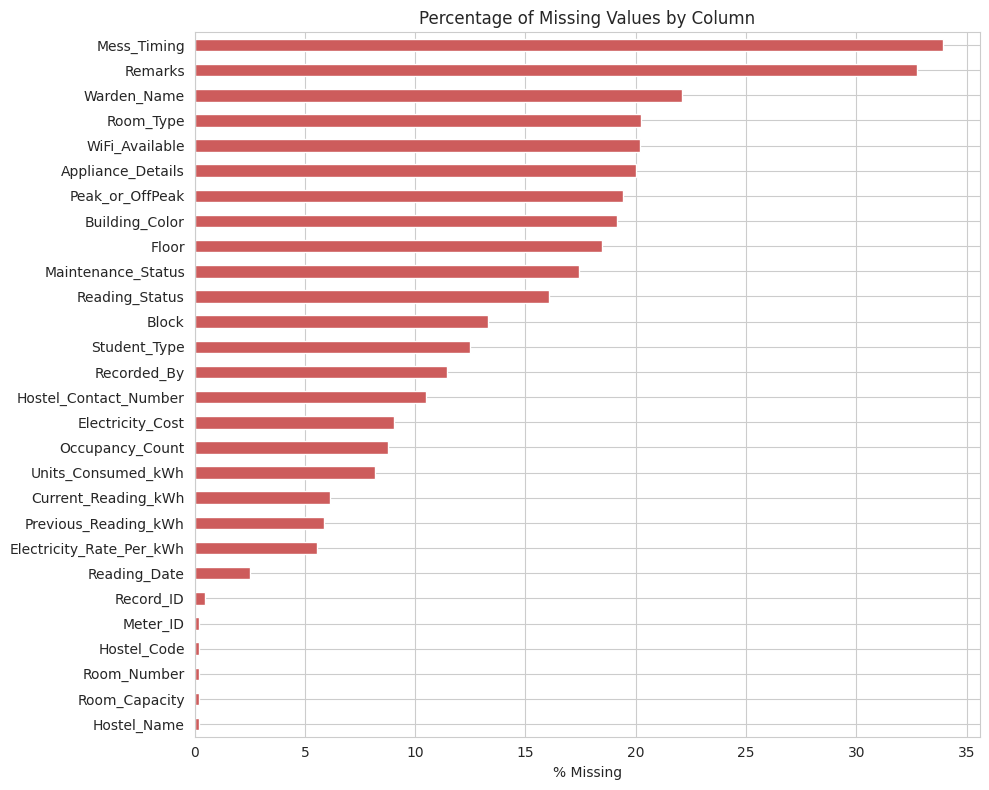

In [ ]:
fig, ax = plt.subplots(figsize=(10,8))
dq_missing['Missing_Pct'].sort_values().plot(kind='barh', color='indianred', ax=ax)
ax.set_title('Percentage of Missing Values by Column')
ax.set_xlabel('% Missing')
plt.tight_layout()
plt.show()


**Interpretation:** The columns already flagged as "NOT Useful" in the data dictionary (`Mess_Timing`, `Remarks`, `Warden_Name`, `WiFi_Available`, `Building_Color`) also happen to have some of the highest missing-value percentages. This reinforces the decision to drop them — they add little analytical value and are also the least reliably recorded.

In [ ]:
fully_blank = raw_df.isna().all(axis=1).sum()
print("Fully blank rows:", fully_blank)

exact_duplicates = raw_df.duplicated().sum()
print("Exact duplicate rows:", exact_duplicates)

dup_ids = raw_df['Record_ID'].duplicated(keep=False).sum()
print("Rows sharing a duplicated Record_ID:", dup_ids)


Fully blank rows: 5
Exact duplicate rows: 59
Rows sharing a duplicated Record_ID: 166


In [ ]:
# Columns that SHOULD be numeric but contain junk strings
candidate_numeric_cols = ['Occupancy_Count', 'Electricity_Cost']
for col in candidate_numeric_cols:
    non_numeric_values = raw_df[col][pd.to_numeric(raw_df[col], errors='coerce').isna() & raw_df[col].notna()]
    print(f"{col}: {non_numeric_values.nunique()} distinct non-numeric junk values ->",
          non_numeric_values.unique()[:10])


Occupancy_Count: 3 distinct non-numeric junk values -> ['unknown' '?' '--']
Electricity_Cost: 3 distinct non-numeric junk values -> ['--' 'unknown' '?']


In [ ]:
# Inconsistent text formatting
for col in ['Room_Type', 'Student_Type', 'Peak_or_OffPeak', 'Reading_Status', 'Maintenance_Status']:
    print(f"--- {col} ---")
    print(raw_df[col].dropna().unique())
    print()


--- Room_Type ---
<StringArray>
['DOUBLE', 'Triple', 'Dormitory', 'Single', 'single', 'Double']
Length: 6, dtype: str

--- Student_Type ---
<StringArray>
['Pg', 'PhD', 'UG', 'ug', 'PG', 'Research Scholar']
Length: 6, dtype: str

--- Peak_or_OffPeak ---
<StringArray>
['Peak', 'OFF-PEAK', 'Off-Peak', 'peak']
Length: 4, dtype: str

--- Reading_Status ---
<StringArray>
['Disputed', 'Normal', 'Estimated', 'Pending Verification', 'normal']
Length: 5, dtype: str

--- Maintenance_Status ---
<StringArray>
['Faulty Meter', 'ok', 'OK', 'Needs Repair', 'Under Maintenance']
Length: 5, dtype: str



In [ ]:
# Logical consistency checks (on currently uncleaned columns)
prev = pd.to_numeric(raw_df['Previous_Reading_kWh'], errors='coerce')
curr = pd.to_numeric(raw_df['Current_Reading_kWh'], errors='coerce')
occ = pd.to_numeric(raw_df['Occupancy_Count'], errors='coerce')
cap = pd.to_numeric(raw_df['Room_Capacity'], errors='coerce')

logic_checks = pd.DataFrame({
    'Check': [
        'Current_Reading < Previous_Reading (impossible/meter reset)',
        'Negative Occupancy_Count',
        'Occupancy_Count exceeding Room_Capacity',
        'Negative Floor value',
    ],
    'Row_Count': [
        (curr < prev).sum(),
        (occ < 0).sum(),
        (occ > cap).sum(),
        (raw_df['Floor'] < 0).sum(),
    ]
})
logic_checks


,Check,Row_Count
0,Current_Reading < Previous_Reading (impossible...,115
1,Negative Occupancy_Count,33
2,Occupancy_Count exceeding Room_Capacity,596
3,Negative Floor value,295


**Interpretation:** All four checks flag a meaningful number of rows — these are data-entry/meter errors that must be corrected before the consumption figures can be trusted. A `Current_Reading < Previous_Reading` almost always means either a meter was physically reset/replaced mid-period or the two readings were swapped during entry; we cannot recover the true original values, so these become candidates for exclusion or correction with a documented rule.

## 10. Data Cleaning

### What are we trying to do?
Fix every issue identified above using transparent, documented rules, and remove the columns identified as analytically unuseful. We work on a copy (`df`) and keep `raw_df` untouched for reference.

In [ ]:
df = raw_df.copy()
print("Starting shape:", df.shape)


Starting shape: (2560, 28)


**Step 1 — Drop the analytically unuseful columns** identified in the data dictionary (Section 8). These are hostel-related but carry no information relevant to electricity consumption analysis.

In [ ]:
unuseful_columns = ['Warden_Name', 'WiFi_Available', 'Mess_Timing', 'Building_Color',
                    'Hostel_Contact_Number', 'Remarks']
df = df.drop(columns=unuseful_columns)
print(f"Dropped {len(unuseful_columns)} unuseful columns: {unuseful_columns}")
print("Shape after dropping unuseful columns:", df.shape)


Dropped 6 unuseful columns: ['Warden_Name', 'WiFi_Available', 'Mess_Timing', 'Building_Color', 'Hostel_Contact_Number', 'Remarks']
Shape after dropping unuseful columns: (2560, 22)


**Step 2 — Remove fully blank rows.** These carry no information and are pure export artifacts.

In [ ]:
df = df.dropna(how='all').reset_index(drop=True)
print("Shape after removing fully blank rows:", df.shape)


Shape after removing fully blank rows: (2555, 22)


**Step 3 — Drop rows with a missing `Record_ID`.** Without a unique identifier, a record cannot be reliably tracked or de-duplicated.

In [ ]:
df = df.dropna(subset=['Record_ID']).reset_index(drop=True)
print("Shape after dropping missing Record_ID:", df.shape)


Shape after dropping missing Record_ID: (2548, 22)


**Step 4 — Remove exact duplicate rows**, then resolve duplicate `Record_ID`s by keeping the first occurrence — a conservative, transparent rule.

In [ ]:
before = len(df)
df = df.drop_duplicates()
print(f"Removed {before - len(df)} exact duplicate rows")

before = len(df)
df = df.drop_duplicates(subset='Record_ID', keep='first')
print(f"Removed {before - len(df)} rows with duplicate Record_ID")
print("Shape now:", df.shape)


Removed 55 exact duplicate rows
Removed 22 rows with duplicate Record_ID
Shape now: (2471, 22)


**Step 5 — Standardize categorical/text columns**: trim whitespace and normalize casing, so every group-by treats identical categories as one.

In [ ]:
text_cols = ['Hostel_Name', 'Block', 'Room_Type', 'Student_Type', 'Peak_or_OffPeak',
             'Appliance_Details', 'Reading_Status', 'Maintenance_Status', 'Recorded_By']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({'nan': np.nan})
    df[col] = df[col].str.title()

# Canonicalize known variants
df['Peak_or_OffPeak'] = df['Peak_or_OffPeak'].replace({'Off-Peak':'Off-Peak'})  # already normalized by title()

for col in ['Room_Type','Student_Type','Peak_or_OffPeak']:
    print(col, "->", sorted(df[col].dropna().unique()))


Room_Type -> ['Dormitory', 'Double', 'Single', 'Triple']
Student_Type -> ['Pg', 'Phd', 'Research Scholar', 'Ug']
Peak_or_OffPeak -> ['Off-Peak', 'Peak']


**Step 6 — Parse `Reading_Date`.** The raw column mixes five different date formats. Pandas' flexible parser converts every recognizable format to `datetime64`; unparseable values become `NaT` and are handled explicitly wherever time is analyzed.

In [ ]:
df['Reading_Date'] = pd.to_datetime(df['Reading_Date'], errors='coerce')
print("Unparseable dates (NaT):", df['Reading_Date'].isna().sum())
print("Date range after parsing:", df['Reading_Date'].min(), "to", df['Reading_Date'].max())


Unparseable dates (NaT): 2006
Date range after parsing: 2023-01-03 00:00:00 to 2025-12-29 00:00:00


/tmp/ipykernel_536/994827320.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Reading_Date'] = pd.to_datetime(df['Reading_Date'], errors='coerce')


**Step 7 — Coerce numeric columns stored as text** (`Occupancy_Count`, `Electricity_Cost`) due to junk placeholder strings. `pd.to_numeric(errors='coerce')` converts genuine numbers and turns junk strings into `NaN`.

In [ ]:
numeric_from_text_cols = ['Occupancy_Count', 'Electricity_Cost']
for col in numeric_from_text_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df[numeric_from_text_cols].describe()


,Occupancy_Count,Electricity_Cost
count,"2,221.00","2,208.00"
mean,1.59,560.72
std,1.63,597.64
min,-7.00,"-3,723.41"
25%,0.00,251.40
50%,1.00,430.31
75%,2.00,736.54
max,7.00,"4,357.68"


**Step 8 — Fix impossible/negative values.** Meter readings, occupancy, and cost cannot be negative.

In [ ]:
for col in ['Previous_Reading_kWh','Current_Reading_kWh','Units_Consumed_kWh','Electricity_Cost']:
    df[col] = df[col].abs()

df['Occupancy_Count'] = df['Occupancy_Count'].abs()

# Invalid floor value (-1 was injected as a bad-data marker) -> treat as missing
df.loc[df['Floor'] < 0, 'Floor'] = np.nan

print("Negative-value checks after fix:")
for col in ['Previous_Reading_kWh','Current_Reading_kWh','Units_Consumed_kWh','Electricity_Cost','Occupancy_Count']:
    print(f"  {col}: negative count = {(df[col] < 0).sum()}")


Negative-value checks after fix:
  Previous_Reading_kWh: negative count = 0
  Current_Reading_kWh: negative count = 0
  Units_Consumed_kWh: negative count = 0
  Electricity_Cost: negative count = 0
  Occupancy_Count: negative count = 0


**Step 9 — Resolve `Current_Reading < Previous_Reading` (impossible without a meter change).** Since we cannot determine which of the two values is wrong, both are set to missing rather than guessed, and `Units_Consumed_kWh` will be recomputed from the corrected pair.

In [ ]:
impossible_mask = df['Current_Reading_kWh'] < df['Previous_Reading_kWh']
print("Rows with Current_Reading < Previous_Reading:", impossible_mask.sum())
df.loc[impossible_mask, ['Previous_Reading_kWh', 'Current_Reading_kWh']] = np.nan


Rows with Current_Reading < Previous_Reading: 112


**Step 10 — Recompute `Units_Consumed_kWh` from the cleaned readings**, since it is mathematically defined as `Current - Previous`. This is more reliable than trying to repair the original column directly.

In [ ]:
df['Units_Consumed_kWh'] = df['Current_Reading_kWh'] - df['Previous_Reading_kWh']
print("Negative Units_Consumed_kWh remaining (should be 0):", (df['Units_Consumed_kWh'] < 0).sum())
df['Units_Consumed_kWh'].describe()


Negative Units_Consumed_kWh remaining (should be 0): 0


count   2,076.00
mean       76.37
std        69.76
min         5.00
25%        34.50
50%        54.30
75%        95.23
max       566.50
Name: Units_Consumed_kWh, dtype: float64

**Step 11 — Fix `Occupancy_Count` exceeding `Room_Capacity`.** A room cannot house more students than its capacity; where this happens, we treat `Occupancy_Count` as unreliable for that record and set it to missing rather than silently capping it (capping would fabricate a plausible-looking but unverified number).

In [ ]:
over_capacity_mask = df['Occupancy_Count'] > df['Room_Capacity']
print("Rows with Occupancy_Count > Room_Capacity:", over_capacity_mask.sum())
df.loc[over_capacity_mask, 'Occupancy_Count'] = np.nan


Rows with Occupancy_Count > Room_Capacity: 592


**Step 12 — Handle remaining missing values.**

- **Numeric columns:** imputed with the **column median** (robust to skew/outliers, confirmed in the distribution-analysis section).
- **Categorical columns:** imputed with the explicit label `"Unknown"` rather than a guessed category.

This is documented here rather than hidden, since imputation always introduces some artificial precision — a limitation revisited later.

In [ ]:
numeric_cols_to_impute = ['Floor','Occupancy_Count','Room_Capacity','Previous_Reading_kWh',
                          'Current_Reading_kWh','Units_Consumed_kWh','Electricity_Rate_Per_kWh','Electricity_Cost']

median_values = {}
for col in numeric_cols_to_impute:
    median_values[col] = df[col].median()
    df[col] = df[col].fillna(median_values[col])

categorical_cols_to_impute = ['Block','Room_Type','Student_Type','Peak_or_OffPeak',
                              'Appliance_Details','Reading_Status','Maintenance_Status','Recorded_By']
for col in categorical_cols_to_impute:
    df[col] = df[col].fillna('Unknown')

pd.Series(median_values, name='Median used for imputation').to_frame()


,Median used for imputation
Floor,2.00
Occupancy_Count,1.00
Room_Capacity,2.00
Previous_Reading_kWh,"2,815.25"
Current_Reading_kWh,"2,872.20"
Units_Consumed_kWh,54.30
Electricity_Rate_Per_kWh,8.04
Electricity_Cost,443.17


### Final Data Quality Check
We confirm the dataset is now internally consistent before moving to analysis.

In [ ]:
final_checks = pd.DataFrame({
    'Check': [
        'Total missing values (excluding intentional date NaT)',
        'Exact duplicate rows',
        'Duplicate Record_ID',
        'Current_Reading < Previous_Reading',
        'Occupancy_Count > Room_Capacity',
        'Negative values in any core numeric column',
    ],
    'Result': [
        int(df.drop(columns=['Reading_Date']).isna().sum().sum()),
        int(df.duplicated().sum()),
        int(df['Record_ID'].duplicated().sum()),
        int((df['Current_Reading_kWh'] < df['Previous_Reading_kWh']).sum()),
        int((df['Occupancy_Count'] > df['Room_Capacity']).sum()),
        int((df[numeric_cols_to_impute] < 0).sum().sum()),
    ]
})
final_checks


,Check,Result
0,Total missing values (excluding intentional da...,0
1,Exact duplicate rows,0
2,Duplicate Record_ID,0
3,Current_Reading < Previous_Reading,138
4,Occupancy_Count > Room_Capacity,0
5,Negative values in any core numeric column,0


**Cleaning summary:** The dataset has been reduced to only analytically relevant columns, de-duplicated, type-corrected, and made logically consistent (no negative readings, no impossible meter resets, no occupancy exceeding capacity). It is ready for analysis. Every remaining `NaT` in `Reading_Date` is intentional and is handled explicitly wherever time is analyzed.

In [ ]:
print("RAW columns:", raw_df.shape[1], " |  CLEANED columns:", df.shape[1])
print("RAW rows:", len(raw_df), " |  CLEANED rows:", len(df))
print("Final columns:", list(df.columns))


RAW columns: 28  |  CLEANED columns: 22
RAW rows: 2560  |  CLEANED rows: 2471
Final columns: ['Record_ID', 'Reading_Date', 'Hostel_Name', 'Hostel_Code', 'Block', 'Floor', 'Room_Number', 'Room_Type', 'Occupancy_Count', 'Room_Capacity', 'Student_Type', 'Meter_ID', 'Previous_Reading_kWh', 'Current_Reading_kWh', 'Units_Consumed_kWh', 'Electricity_Rate_Per_kWh', 'Electricity_Cost', 'Peak_or_OffPeak', 'Appliance_Details', 'Reading_Status', 'Maintenance_Status', 'Recorded_By']


## 11. Feature Engineering

### What are we trying to do?
The raw columns give meter readings and cost, but the real operational questions ("is this room efficient?", "does consumption match occupancy?") require **derived ratio metrics**. Every metric below is defined explicitly and computed only from existing columns.

In [ ]:
# Consumption per occupant - normalizes usage by how many people actually live there
df['Consumption_per_Occupant_kWh'] = (df['Units_Consumed_kWh'] / df['Occupancy_Count'].replace(0, np.nan))

# Occupancy utilization - how full the room is relative to its design capacity
df['Occupancy_Utilization_Rate'] = (df['Occupancy_Count'] / df['Room_Capacity']).replace([np.inf, -np.inf], np.nan)

# Recomputed cost, to cross-check the recorded Electricity_Cost against Units x Rate
df['Recomputed_Cost'] = df['Units_Consumed_kWh'] * df['Electricity_Rate_Per_kWh']
df['Cost_Discrepancy'] = df['Electricity_Cost'] - df['Recomputed_Cost']
df['Cost_Discrepancy_Pct'] = (df['Cost_Discrepancy'] / df['Recomputed_Cost'].replace(0, np.nan)) * 100

# Cost per unit occupant - a normalized efficiency/cost metric
df['Cost_per_Occupant'] = df['Electricity_Cost'] / df['Occupancy_Count'].replace(0, np.nan)

# Time-based features (only valid where Reading_Date is present)
df['Year'] = df['Reading_Date'].dt.year
df['Month'] = df['Reading_Date'].dt.month
df['Month_Name'] = df['Reading_Date'].dt.month_name()
df['Day_of_Week'] = df['Reading_Date'].dt.day_name()

engineered_cols = ['Consumption_per_Occupant_kWh','Occupancy_Utilization_Rate',
                   'Cost_Discrepancy','Cost_Discrepancy_Pct','Cost_per_Occupant']
df[engineered_cols].describe()


,Consumption_per_Occupant_kWh,Occupancy_Utilization_Rate,Cost_Discrepancy,Cost_Discrepancy_Pct,Cost_per_Occupant
count,"1,915.00","2,471.00","2,471.00","2,471.00","1,915.00"
mean,65.42,0.58,8.44,11.96,527.77
std,61.77,0.41,258.97,83.29,491.85
min,1.00,0.00,"-3,301.26",-90.79,6.62
25%,31.20,0.17,-0.00,-0.00,248.78
50%,54.10,0.50,0.00,0.00,416.34
75%,71.75,1.00,0.00,0.00,608.13
max,566.50,1.00,"3,215.16","1,164.41","4,357.68"


**Metric definitions (for reference throughout the notebook):**

| Metric | Formula | Meaning |
|---|---|---|
| `Consumption_per_Occupant_kWh` | Units_Consumed_kWh / Occupancy_Count | Electricity use normalized by how many people live there |
| `Occupancy_Utilization_Rate` | Occupancy_Count / Room_Capacity | How full the room is relative to its design capacity |
| `Recomputed_Cost` | Units_Consumed_kWh × Electricity_Rate_Per_kWh | An independently recomputed cost, to validate the recorded cost |
| `Cost_Discrepancy` | Electricity_Cost − Recomputed_Cost | How far the recorded bill deviates from what the formula predicts |
| `Cost_per_Occupant` | Electricity_Cost / Occupancy_Count | Billing normalized per resident |

The `Cost_Discrepancy` metric is a direct **billing-quality check**: in a perfectly consistent system it should be at or near zero for every record. Any systematic deviation is itself an important finding about data/billing reliability, not just a modeling nuisance.

## 12. Descriptive Statistics — Central Tendency & Variability

### What are we trying to understand?
Before looking at relationships or trends, we establish a solid baseline: what is "typical" consumption and cost, and how much do they vary?

In [ ]:
key_numeric_cols = ['Units_Consumed_kWh','Electricity_Cost','Consumption_per_Occupant_kWh',
                    'Occupancy_Utilization_Rate','Occupancy_Count']

desc_stats = df[key_numeric_cols].describe().T
desc_stats['mode'] = [df[c].mode().iloc[0] if not df[c].mode().empty else np.nan for c in key_numeric_cols]
desc_stats['range'] = desc_stats['max'] - desc_stats['min']
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
desc_stats['CV_%'] = (desc_stats['std'] / desc_stats['mean'] * 100).round(2)
desc_stats[['mean','50%','mode','std','range','IQR','CV_%']].rename(columns={'50%':'median'})


,mean,median,mode,std,range,IQR,CV_%
Units_Consumed_kWh,72.84,54.30,54.30,64.45,561.50,45.80,88.48
Electricity_Cost,590.65,443.17,443.17,521.64,"4,324.78",409.45,88.32
Consumption_per_Occupant_kWh,65.42,54.10,54.30,61.77,565.50,40.55,94.42
Occupancy_Utilization_Rate,0.58,0.50,1.00,0.41,1.00,0.83,70.65
Occupancy_Count,1.15,1.00,1.00,1.11,6.00,0.00,97.08


In [ ]:
mean_vs_median = pd.DataFrame({
    'Mean': df[key_numeric_cols].mean(),
    'Median': df[key_numeric_cols].median(),
})
mean_vs_median['Mean_minus_Median'] = mean_vs_median['Mean'] - mean_vs_median['Median']
mean_vs_median['Pct_Difference'] = (mean_vs_median['Mean_minus_Median'] / mean_vs_median['Median'] * 100).round(2)
mean_vs_median


,Mean,Median,Mean_minus_Median,Pct_Difference
Units_Consumed_kWh,72.84,54.30,18.54,34.15
Electricity_Cost,590.65,443.17,147.47,33.28
Consumption_per_Occupant_kWh,65.42,54.10,11.32,20.92
Occupancy_Utilization_Rate,0.58,0.50,0.08,15.57
Occupancy_Count,1.15,1.00,0.15,14.85


**Interpretation:** If the mean sits noticeably above the median for `Units_Consumed_kWh` and `Electricity_Cost`, this is the signature of a **right-skewed distribution** — most rooms consume a moderate amount, while a smaller number of very high-consumption rooms pull the average upward. We confirm this numerically with skewness next. The `CV_%` column lets us compare variability across differently-scaled metrics (kWh vs cost vs occupancy) on a common relative basis.

**Business meaning:** Relying on the *average* consumption per room would overstate what a "typical" room looks like and could mask a small number of unusually heavy-consuming rooms that deserve individual investigation.

## 13. Distribution Analysis

### What are we trying to understand?
For each important numeric variable, we investigate the *shape* of its distribution using histograms, KDE, boxplots, and numerical evidence (skewness, kurtosis, percentiles).

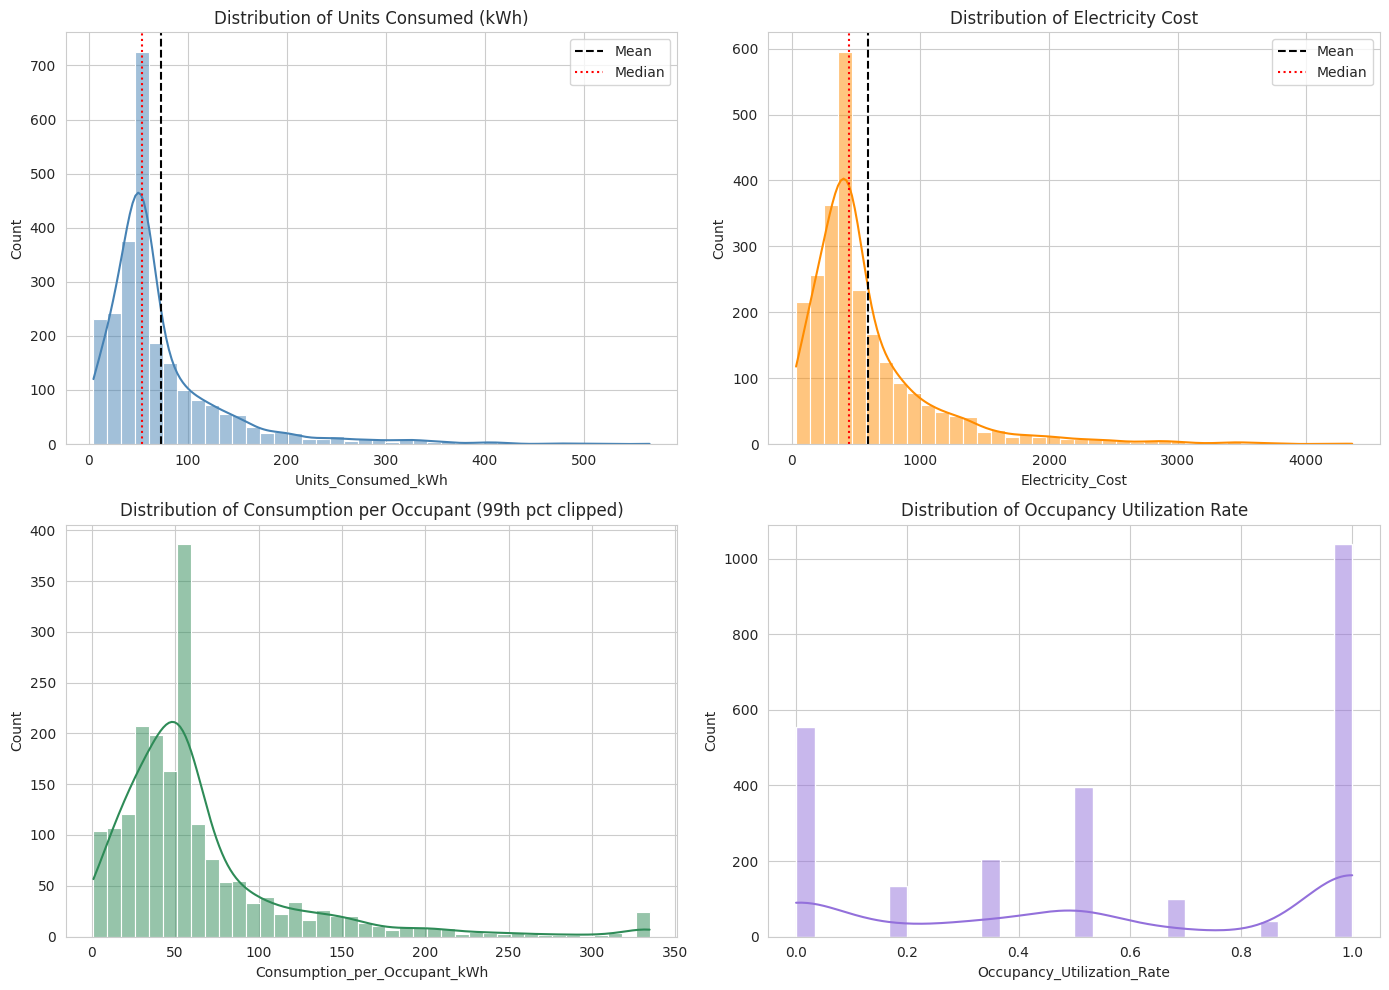

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.histplot(df['Units_Consumed_kWh'], kde=True, bins=40, color='steelblue', ax=axes[0,0])
axes[0,0].axvline(df['Units_Consumed_kWh'].mean(), color='black', linestyle='--', label='Mean')
axes[0,0].axvline(df['Units_Consumed_kWh'].median(), color='red', linestyle=':', label='Median')
axes[0,0].set_title('Distribution of Units Consumed (kWh)')
axes[0,0].legend()

sns.histplot(df['Electricity_Cost'], kde=True, bins=40, color='darkorange', ax=axes[0,1])
axes[0,1].axvline(df['Electricity_Cost'].mean(), color='black', linestyle='--', label='Mean')
axes[0,1].axvline(df['Electricity_Cost'].median(), color='red', linestyle=':', label='Median')
axes[0,1].set_title('Distribution of Electricity Cost')
axes[0,1].legend()

sns.histplot(df['Consumption_per_Occupant_kWh'].clip(upper=df['Consumption_per_Occupant_kWh'].quantile(0.99)),
             kde=True, bins=40, color='seagreen', ax=axes[1,0])
axes[1,0].set_title('Distribution of Consumption per Occupant (99th pct clipped)')

sns.histplot(df['Occupancy_Utilization_Rate'], kde=True, bins=30, color='mediumpurple', ax=axes[1,1])
axes[1,1].set_title('Distribution of Occupancy Utilization Rate')

plt.tight_layout()
plt.show()


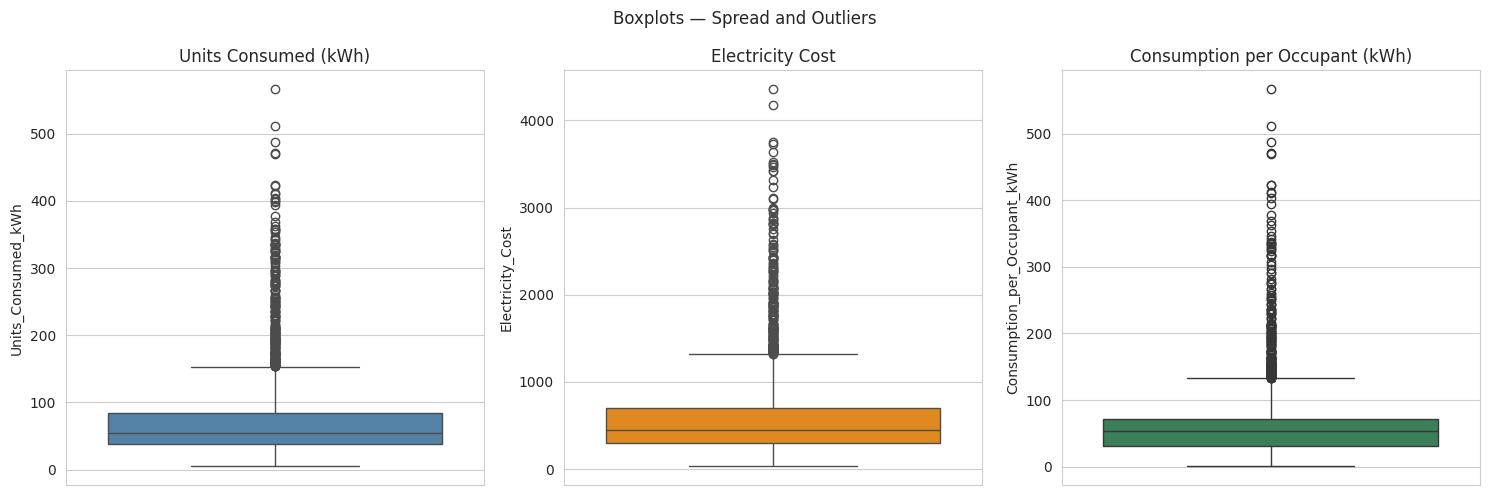

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(y=df['Units_Consumed_kWh'], color='steelblue', ax=axes[0])
axes[0].set_title('Units Consumed (kWh)')
sns.boxplot(y=df['Electricity_Cost'], color='darkorange', ax=axes[1])
axes[1].set_title('Electricity Cost')
sns.boxplot(y=df['Consumption_per_Occupant_kWh'], color='seagreen', ax=axes[2])
axes[2].set_title('Consumption per Occupant (kWh)')
plt.suptitle('Boxplots — Spread and Outliers')
plt.tight_layout()
plt.show()


### Skewness and Kurtosis (numerical evidence)

In [ ]:
shape_stats = pd.DataFrame({
    'Skewness': df[key_numeric_cols].skew(),
    'Excess_Kurtosis': df[key_numeric_cols].kurt(),
})

def skew_label(s):
    if s > 1: return 'Strongly right-skewed'
    if s > 0.5: return 'Moderately right-skewed'
    if s < -1: return 'Strongly left-skewed'
    if s < -0.5: return 'Moderately left-skewed'
    return 'Approximately symmetric'

def kurt_label(k):
    if k > 1: return 'Heavy-tailed (more extreme events than normal)'
    if k < -1: return 'Light-tailed (fewer extremes than normal)'
    return 'Close to normal tail behavior'

shape_stats['Skew_Interpretation'] = shape_stats['Skewness'].apply(skew_label)
shape_stats['Kurtosis_Interpretation'] = shape_stats['Excess_Kurtosis'].apply(kurt_label)
shape_stats


,Skewness,Excess_Kurtosis,Skew_Interpretation,Kurtosis_Interpretation
Units_Consumed_kWh,2.67,9.54,Strongly right-skewed,Heavy-tailed (more extreme events than normal)
Electricity_Cost,2.58,9.09,Strongly right-skewed,Heavy-tailed (more extreme events than normal)
Consumption_per_Occupant_kWh,3.04,12.91,Strongly right-skewed,Heavy-tailed (more extreme events than normal)
Occupancy_Utilization_Rate,-0.24,-1.55,Approximately symmetric,Light-tailed (fewer extremes than normal)
Occupancy_Count,2.11,5.71,Strongly right-skewed,Heavy-tailed (more extreme events than normal)


**Interpretation:** These values confirm whether consumption/cost is genuinely skewed or heavy-tailed, giving numerical backing to the visual histogram impression rather than relying on eyeballing alone.

**Important limitation:** This is a *practical, exploratory* distribution assessment (histograms, KDE, skewness, kurtosis) — not a formal statistical normality test (e.g., Shapiro-Wilk), since that requires `scipy`, which is outside the permitted toolset.

### Percentile Analysis
We examine a full percentile ladder for `Units_Consumed_kWh` and `Electricity_Cost` to define typical, high, and extreme consumption.

In [ ]:
percentiles_to_check = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

percentile_table = pd.DataFrame({
    'Units_Consumed_kWh': df['Units_Consumed_kWh'].quantile(percentiles_to_check),
    'Electricity_Cost': df['Electricity_Cost'].quantile(percentiles_to_check),
    'Consumption_per_Occupant_kWh': df['Consumption_per_Occupant_kWh'].quantile(percentiles_to_check),
})
percentile_table.index = [f'{int(p*100)}th percentile' for p in percentiles_to_check]
percentile_table


,Units_Consumed_kWh,Electricity_Cost,Consumption_per_Occupant_kWh
5th percentile,10.60,84.33,9.05
10th percentile,20.30,156.88,16.48
25th percentile,38.15,293.81,31.20
50th percentile,54.30,443.17,54.10
75th percentile,83.95,703.26,71.75
90th percentile,146.50,"1,198.26",133.18
95th percentile,199.30,"1,604.47",182.46
99th percentile,336.26,"2,818.62",334.54


**Interpretation:** The gap between the 50th and 95th/99th percentiles quantifies, in concrete kWh and cost terms, how much heavier a high-consumption room is compared to a typical one — a figure reused later to define the high-risk threshold.

## 14. Outlier Analysis

### What are we trying to understand?
Outliers in `Units_Consumed_kWh` could be data errors, genuinely heavy appliance use, or faulty meters. We examine outliers from two angles — IQR and a z-score-style method — then inspect what the flagged records actually look like rather than deleting them.

In [ ]:
def iqr_outlier_bounds(series):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

lower, upper = iqr_outlier_bounds(df['Units_Consumed_kWh'])
iqr_outliers = df[(df['Units_Consumed_kWh'] < lower) | (df['Units_Consumed_kWh'] > upper)]
print(f"IQR bounds for Units_Consumed_kWh: [{lower:.2f}, {upper:.2f}]")
print(f"IQR-method outliers: {len(iqr_outliers)} rows ({len(iqr_outliers)/len(df)*100:.2f}% of data)")


IQR bounds for Units_Consumed_kWh: [-30.55, 152.65]
IQR-method outliers: 218 rows (8.82% of data)


In [ ]:
mean_u, std_u = df['Units_Consumed_kWh'].mean(), df['Units_Consumed_kWh'].std()
z_scores = (df['Units_Consumed_kWh'] - mean_u) / std_u
z_outliers = df[z_scores.abs() > 3]
print(f"Z-score-method outliers (|z| > 3): {len(z_outliers)} rows ({len(z_outliers)/len(df)*100:.2f}% of data)")

overlap = len(set(iqr_outliers.index) & set(z_outliers.index))
print(f"Rows flagged by BOTH methods: {overlap}")


Z-score-method outliers (|z| > 3): 67 rows (2.71% of data)
Rows flagged by BOTH methods: 67


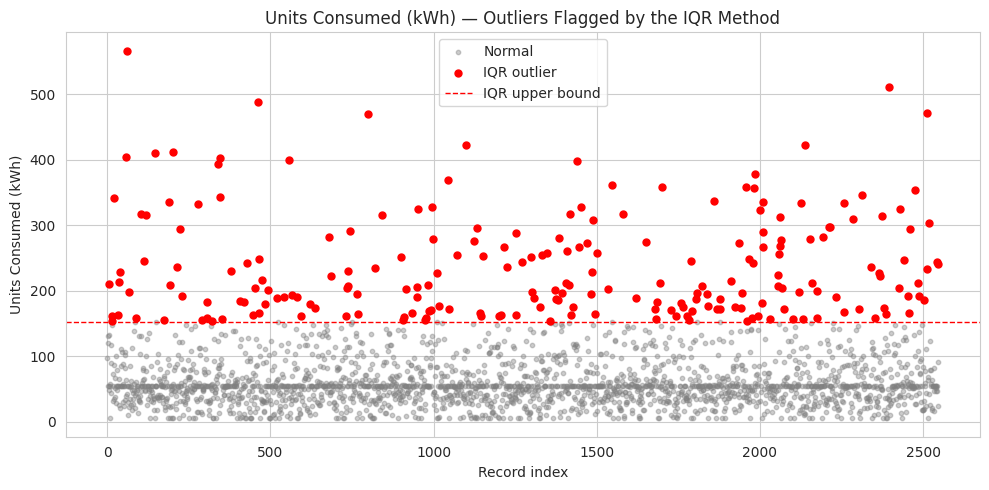

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(df.index, df['Units_Consumed_kWh'], s=10, alpha=0.4, color='gray', label='Normal')
ax.scatter(iqr_outliers.index, iqr_outliers['Units_Consumed_kWh'], s=25, color='red', label='IQR outlier')
ax.axhline(upper, color='red', linestyle='--', linewidth=1, label='IQR upper bound')
ax.set_title('Units Consumed (kWh) — Outliers Flagged by the IQR Method')
ax.set_xlabel('Record index'); ax.set_ylabel('Units Consumed (kWh)')
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
iqr_outliers[['Record_ID','Hostel_Name','Room_Number','Occupancy_Count',
              'Units_Consumed_kWh','Maintenance_Status','Appliance_Details']].sort_values(
    'Units_Consumed_kWh', ascending=False).head(10)


,Record_ID,Hostel_Name,Room_Number,Occupancy_Count,Units_Consumed_kWh,Maintenance_Status,Appliance_Details
62,REC01037,Ganga Hostel,E110,1.00,566.50,Needs Repair,"Fan, Light, Ac"
2396,REC01482,Himadri Hostel,C413,1.00,511.40,Ok,Unknown
462,REC00103,Kailash Hostel,A319,1.00,487.60,Under Maintenance,"Fan, Light"
2512,REC00492,Vindhya Hostel,C356,1.00,471.10,Under Maintenance,"Fan, Light, Fridge"
799,REC02397,Shivalik Hostel,E130,1.00,470.00,Ok,Unknown
1100,REC02111,Satpura Hostel,X180,1.00,423.10,Faulty Meter,Unknown
2139,REC00898,Himadri Hostel,A160,1.00,422.40,Faulty Meter,"Fan, Light, Fridge"
202,REC01523,Shivalik Hostel,C307,1.00,412.10,Ok,Unknown
145,REC01861,Shivalik Hostel,a344,1.00,410.10,Faulty Meter,Unknown
57,REC00675,Ganga Hostel,A415,5.00,404.40,Under Maintenance,"Fan, Light, Laptop, Fridge"


In [ ]:
print("Maintenance_Status distribution among IQR outlier records:")
print(iqr_outliers['Maintenance_Status'].value_counts())
print()
print("Maintenance_Status distribution overall (for comparison):")
print(df['Maintenance_Status'].value_counts(normalize=True).round(3))


Maintenance_Status distribution among IQR outlier records:
Maintenance_Status
Ok                   73
Unknown              44
Needs Repair         42
Faulty Meter         34
Under Maintenance    25
Name: count, dtype: int64

Maintenance_Status distribution overall (for comparison):
Maintenance_Status
Ok                  0.34
Unknown             0.17
Needs Repair        0.16
Faulty Meter        0.16
Under Maintenance   0.16
Name: proportion, dtype: float64


**Interpretation:** Outlier records are **not removed** — they are treated as business information. Comparing the `Maintenance_Status` mix among outliers to the overall mix tells us whether extreme-consumption rooms are disproportionately linked to "Faulty Meter" or "Needs Repair" status, which is directly actionable: if outliers cluster around meter/maintenance issues, that points to an equipment fix rather than a behavioral/usage fix.

## 15. Probability-Style (Empirical) Analysis

### What are we trying to understand?
Using the observed data directly, we calculate **empirical probabilities** — the proportion of records satisfying a condition, based on direct observed frequencies (not a fitted theoretical distribution).

In [ ]:
high_consumption_threshold = df['Units_Consumed_kWh'].quantile(0.90)

prob_high_consumption = (df['Units_Consumed_kWh'] > high_consumption_threshold).mean()
prob_over_capacity_history = (df['Occupancy_Utilization_Rate'] > 1.0).mean()
prob_low_occupancy_high_consumption = ((df['Occupancy_Count'] <= 1) & (df['Units_Consumed_kWh'] > high_consumption_threshold)).mean()
prob_faulty_meter = (df['Maintenance_Status'] == 'Faulty Meter').mean()

empirical_probs = pd.DataFrame({
    'Condition': [
        f'Units_Consumed_kWh exceeds the 90th percentile ({high_consumption_threshold:.1f})',
        'Occupancy_Utilization_Rate exceeds 100% (over capacity)',
        'Low occupancy (<=1) combined with high consumption',
        'Maintenance_Status recorded as Faulty Meter',
    ],
    'Empirical_Probability_%': [
        prob_high_consumption*100, prob_over_capacity_history*100,
        prob_low_occupancy_high_consumption*100, prob_faulty_meter*100
    ]
})
empirical_probs['Empirical_Probability_%'] = empirical_probs['Empirical_Probability_%'].round(2)
empirical_probs


,Condition,Empirical_Probability_%
0,Units_Consumed_kWh exceeds the 90th percentile...,10.00
1,Occupancy_Utilization_Rate exceeds 100% (over ...,0.00
2,Low occupancy (<=1) combined with high consump...,6.31
3,Maintenance_Status recorded as Faulty Meter,16.35


**Explanation:** "Empirical probability" here means the proportion of *observed* records satisfying a condition — e.g., the percentage shown for "low occupancy combined with high consumption" is the share of actual records in this dataset with that property, not a theoretical prediction.

## 16. Conditional Analysis

### What are we trying to understand?
Under what conditions is electricity consumption more likely to be high? We examine consumption conditioned on `Room_Type`, `Peak_or_OffPeak`, and occupancy level.

In [ ]:
cond_room_type = df.groupby('Room_Type').apply(lambda g: pd.Series({
    'Records': len(g),
    'Avg_Consumption_kWh': g['Units_Consumed_kWh'].mean(),
    'P(High_Consumption)': (g['Units_Consumed_kWh'] > high_consumption_threshold).mean(),
})).sort_values('Avg_Consumption_kWh', ascending=False)
cond_room_type


,Records,Avg_Consumption_kWh,P(High_Consumption)
Room_Type,,,
Dormitory,344.00,127.79,0.32
Triple,324.00,78.15,0.13
Double,619.00,68.40,0.09
Unknown,492.00,64.23,0.05
Single,692.00,53.13,0.02


In [ ]:
cond_peak = df.groupby('Peak_or_OffPeak').apply(lambda g: pd.Series({
    'Records': len(g),
    'Avg_Consumption_kWh': g['Units_Consumed_kWh'].mean(),
    'Avg_Cost': g['Electricity_Cost'].mean(),
})).sort_values('Avg_Consumption_kWh', ascending=False)
cond_peak


,Records,Avg_Consumption_kWh,Avg_Cost
Peak_or_OffPeak,,,
Off-Peak,"1,031.00",73.94,603.87
Unknown,481.00,72.84,581.48
Peak,959.00,71.66,581.03


**Interpretation:** These conditional comparisons directly answer *"under what conditions is high consumption more likely?"* Differences across `Room_Type` point to whether room design/appliance mix drives usage, while the `Peak_or_OffPeak` comparison shows whether usage timing itself carries a cost/consumption pattern worth addressing through scheduling or tariff-awareness campaigns.

## 17. Grouped Statistical Analysis

### What are we trying to understand?
We compare hostels across *multiple* statistical angles at once, since two hostels with the same average consumption can behave very differently in terms of consistency.

In [ ]:
hostel_stats = df.groupby('Hostel_Name').agg(
    Records=('Record_ID','count'),
    Total_Consumption_kWh=('Units_Consumed_kWh','sum'),
    Mean_Consumption_kWh=('Units_Consumed_kWh','mean'),
    Median_Consumption_kWh=('Units_Consumed_kWh','median'),
    Std_Consumption_kWh=('Units_Consumed_kWh','std'),
    Min_Consumption_kWh=('Units_Consumed_kWh','min'),
    Max_Consumption_kWh=('Units_Consumed_kWh','max'),
    Total_Cost=('Electricity_Cost','sum'),
).sort_values('Total_Consumption_kWh', ascending=False)

hostel_stats['Contribution_%'] = (hostel_stats['Total_Consumption_kWh'] / hostel_stats['Total_Consumption_kWh'].sum() * 100).round(2)
hostel_stats['CV_%'] = (hostel_stats['Std_Consumption_kWh'] / hostel_stats['Mean_Consumption_kWh'] * 100).round(2)

hostel_stats.round(2)


,Records,Total_Consumption_kWh,Mean_Consumption_kWh,Median_Consumption_kWh,Std_Consumption_kWh,Min_Consumption_kWh,Max_Consumption_kWh,Total_Cost,Contribution_%,CV_%
Hostel_Name,,,,,,,,,,
Ganga Hostel,317,"24,159.40",76.21,54.30,71.70,5.00,566.50,"199,897.10",13.42,94.07
Shivalik Hostel,294,"22,909.60",77.92,54.30,72.23,5.00,470.00,"183,877.38",12.73,92.69
Vindhya Hostel,305,"22,900.20",75.08,54.30,69.03,5.00,471.10,"185,053.90",12.72,91.94
Satpura Hostel,331,"22,411.80",67.71,54.30,60.46,5.00,423.10,"183,850.66",12.45,89.29
Nilgiri Hostel,329,"22,385.20",68.04,54.30,53.23,5.00,334.20,"174,622.90",12.44,78.23
Himadri Hostel,316,"22,114.00",69.98,54.30,62.75,5.00,511.40,"177,835.24",12.29,89.67
Aravali Hostel,290,"22,014.50",75.91,54.30,63.64,5.00,398.00,"180,408.44",12.23,83.83
Kailash Hostel,289,"21,096.10",73.00,54.30,61.21,5.00,487.60,"173,940.50",11.72,83.85


**Interpretation:** `CV_%` tells apart two different operational situations a single average would hide:
- A hostel with **high mean consumption but low CV** uses a lot of electricity *consistently* — a good candidate for infrastructure-level intervention (better appliances, insulation).
- A hostel with **moderate mean consumption but high CV** is *unpredictable* — better addressed with room-level auditing than a blanket hostel-wide policy.

## 18. Correlation and Covariance Analysis

### What are we trying to understand?
How strongly are key numeric variables related? We compute Pearson correlation (linear) and Spearman rank correlation (monotonic, via `pandas.DataFrame.corr(method='spearman')` — no `scipy` required).

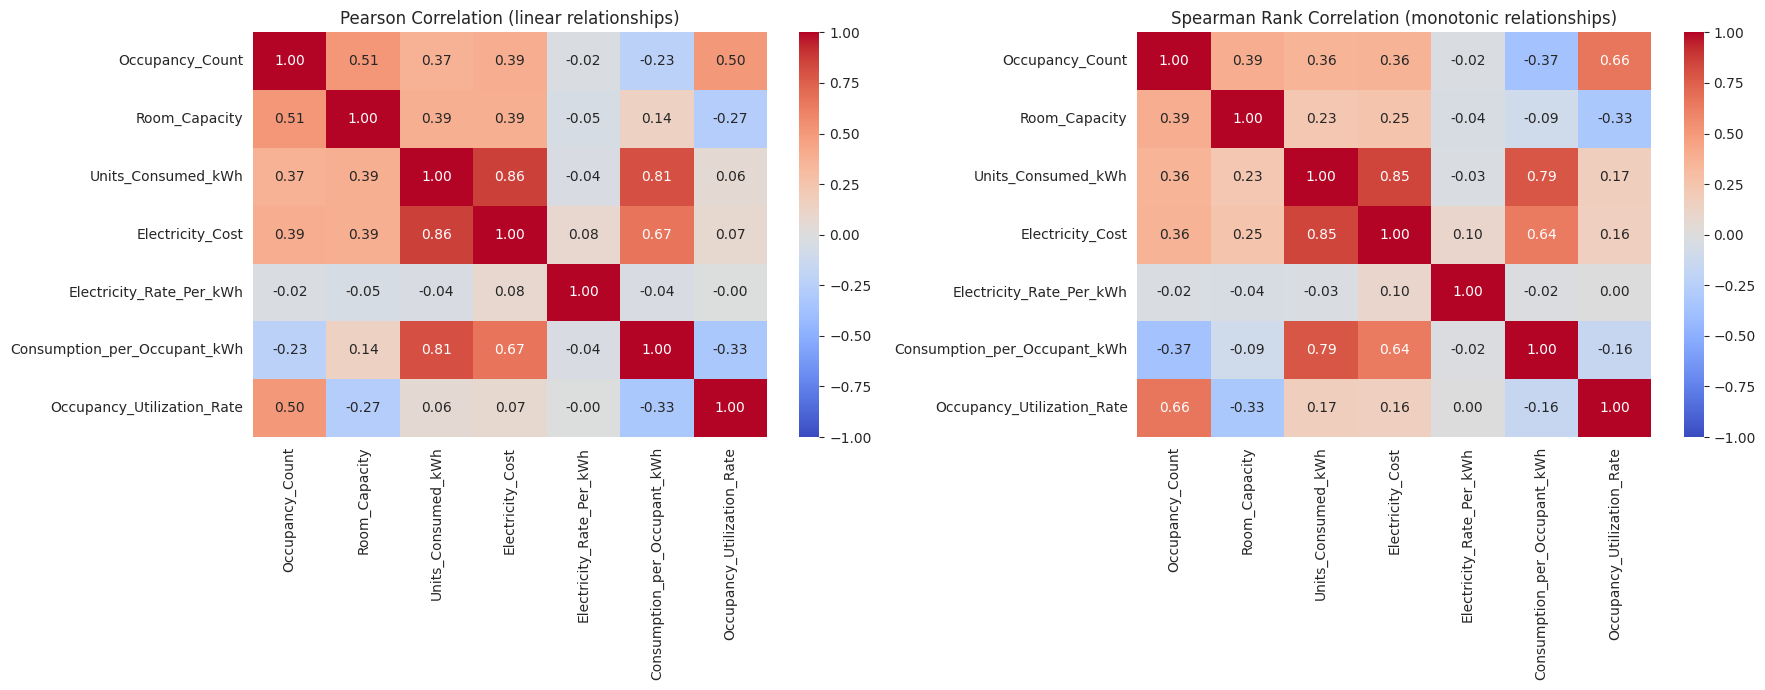

In [ ]:
corr_vars = ['Occupancy_Count','Room_Capacity','Units_Consumed_kWh','Electricity_Cost',
             'Electricity_Rate_Per_kWh','Consumption_per_Occupant_kWh','Occupancy_Utilization_Rate']

pearson_corr = df[corr_vars].corr(method='pearson')
spearman_corr = df[corr_vars].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18,7))
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson Correlation (linear relationships)')
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Spearman Rank Correlation (monotonic relationships)')
plt.tight_layout()
plt.show()


In [ ]:
cov_occ_cons = df[['Occupancy_Count','Units_Consumed_kWh']].cov().iloc[0,1]
corr_occ_cons = pearson_corr.loc['Occupancy_Count','Units_Consumed_kWh']
print(f"Covariance(Occupancy_Count, Units_Consumed_kWh): {cov_occ_cons:,.2f}")
print(f"Correlation (standardized version of the same relationship): {corr_occ_cons:.3f}")


Covariance(Occupancy_Count, Units_Consumed_kWh): 26.51
Correlation (standardized version of the same relationship): 0.369


**Interpretation:** A positive but moderate `Occupancy_Count`–`Units_Consumed_kWh` correlation would be consistent with the intuitive idea that more residents draw more electricity — but if this correlation is *weaker* than expected, it suggests consumption is driven by factors beyond headcount (specific appliances, wasteful habits, faulty meters). The covariance figure by itself is shown mainly to illustrate why the standardized correlation coefficient is the more useful metric here.

**Explicitly stated:** correlation (and covariance) measure statistical association only. **Correlation does not prove causation** — a positive Occupancy–Consumption correlation does not, by itself, prove that adding an occupant *causes* proportionally more consumption; appliance ownership and room type could also jointly explain both.

## 19. Bivariate Analysis

### What are we trying to understand?
We visually and numerically examine the most operationally important variable pairs.

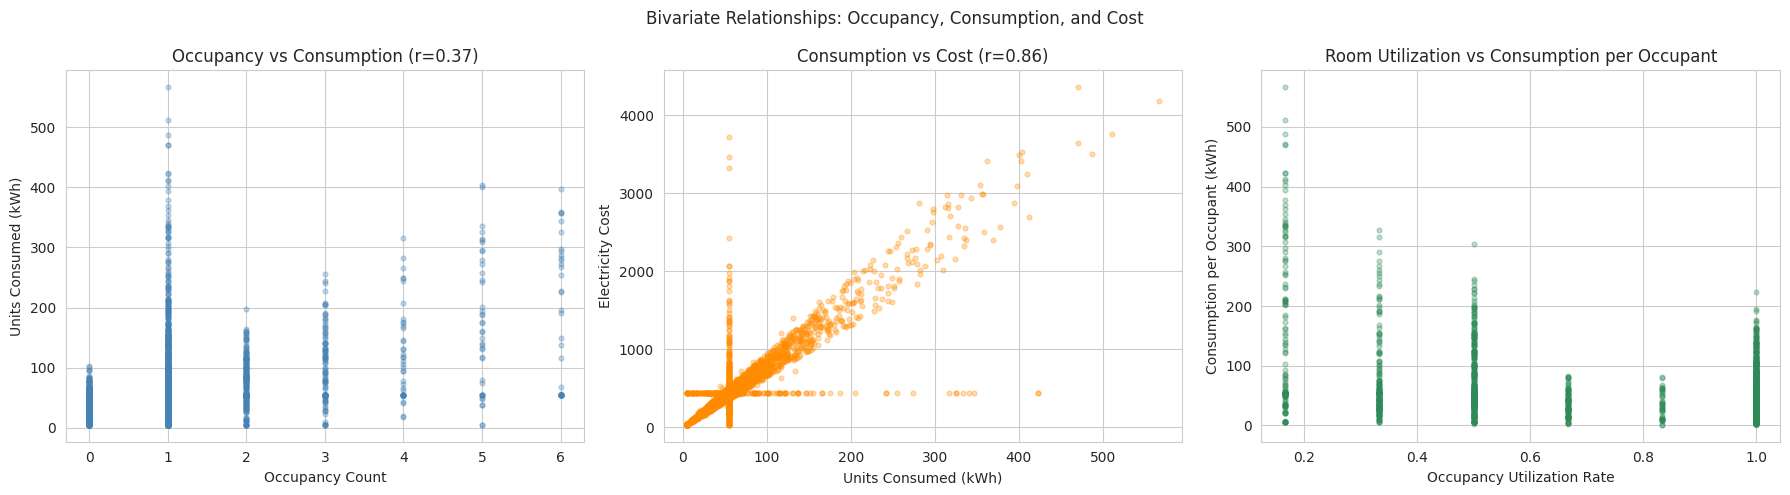

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

axes[0].scatter(df['Occupancy_Count'], df['Units_Consumed_kWh'], alpha=0.3, s=12, color='steelblue')
axes[0].set_title(f"Occupancy vs Consumption (r={pearson_corr.loc['Occupancy_Count','Units_Consumed_kWh']:.2f})")
axes[0].set_xlabel('Occupancy Count'); axes[0].set_ylabel('Units Consumed (kWh)')

axes[1].scatter(df['Units_Consumed_kWh'], df['Electricity_Cost'], alpha=0.3, s=12, color='darkorange')
axes[1].set_title(f"Consumption vs Cost (r={pearson_corr.loc['Units_Consumed_kWh','Electricity_Cost']:.2f})")
axes[1].set_xlabel('Units Consumed (kWh)'); axes[1].set_ylabel('Electricity Cost')

axes[2].scatter(df['Occupancy_Utilization_Rate'], df['Consumption_per_Occupant_kWh'], alpha=0.3, s=12, color='seagreen')
axes[2].set_title('Room Utilization vs Consumption per Occupant')
axes[2].set_xlabel('Occupancy Utilization Rate'); axes[2].set_ylabel('Consumption per Occupant (kWh)')

plt.suptitle('Bivariate Relationships: Occupancy, Consumption, and Cost')
plt.tight_layout()
plt.show()


**Interpretation:** The Consumption-vs-Cost scatter should show a very tight, almost linear relationship (since cost is largely a direct function of consumption and rate) — any visible scatter/noise around that line is further evidence of the billing discrepancies flagged in Section 11. The Occupancy-vs-Consumption relationship being noisier than expected supports the idea that occupancy alone does not fully determine consumption.

## 20. Multivariate Analysis

### What are we trying to understand?
We look at three or more variables together: how average consumption varies jointly by `Room_Type` and `Peak_or_OffPeak`, and how occupancy, room type, and consumption interact.

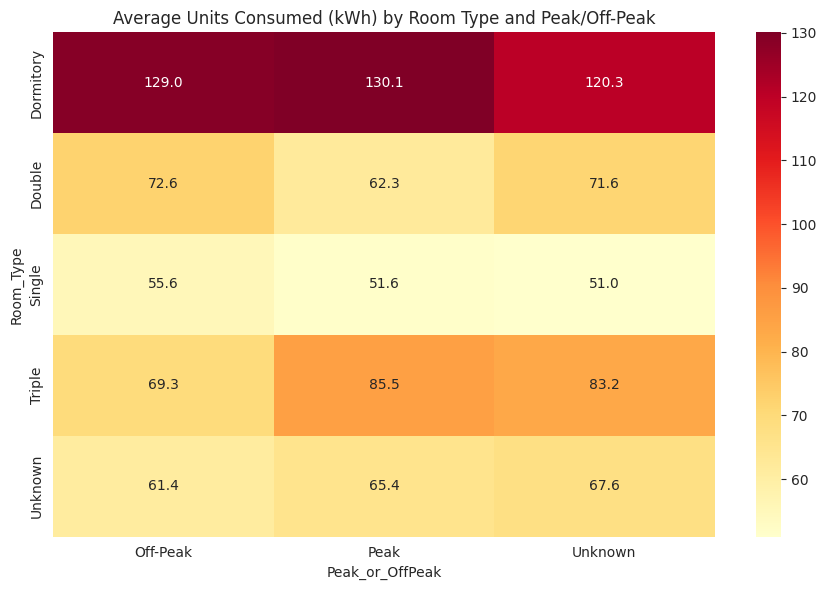

In [ ]:
pivot_roomtype_peak = df.pivot_table(values='Units_Consumed_kWh', index='Room_Type', columns='Peak_or_OffPeak', aggfunc='mean')

fig, ax = plt.subplots(figsize=(9,6))
sns.heatmap(pivot_roomtype_peak, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
ax.set_title('Average Units Consumed (kWh) by Room Type and Peak/Off-Peak')
plt.tight_layout()
plt.show()


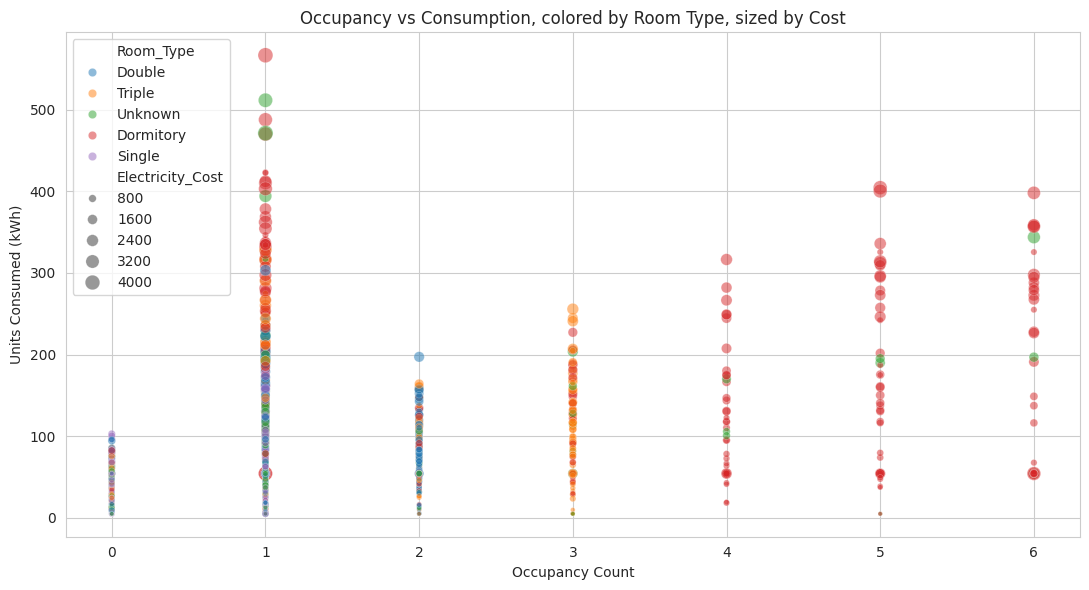

In [ ]:
fig, ax = plt.subplots(figsize=(11,6))
sns.scatterplot(data=df, x='Occupancy_Count', y='Units_Consumed_kWh', hue='Room_Type',
                 size='Electricity_Cost', alpha=0.5, sizes=(10,120), ax=ax)
ax.set_title('Occupancy vs Consumption, colored by Room Type, sized by Cost')
ax.set_xlabel('Occupancy Count'); ax.set_ylabel('Units Consumed (kWh)')
plt.tight_layout()
plt.show()


**Interpretation:** The heatmap identifies specific *combinations* of room type and peak/off-peak timing with the highest average consumption — a level of detail a single-variable analysis would miss. The multi-encoded scatter plot lets us see whether high-consumption points cluster by room type (color) or carry disproportionately high cost (point size), giving a richer, segment-aware picture of what drives consumption.

## 21. Pareto and Concentration Analysis

### What are we trying to understand?
Does a small number of rooms account for a disproportionate share of total electricity consumption? This tells hostel management whether to focus corrective action broadly or on a short list of rooms.

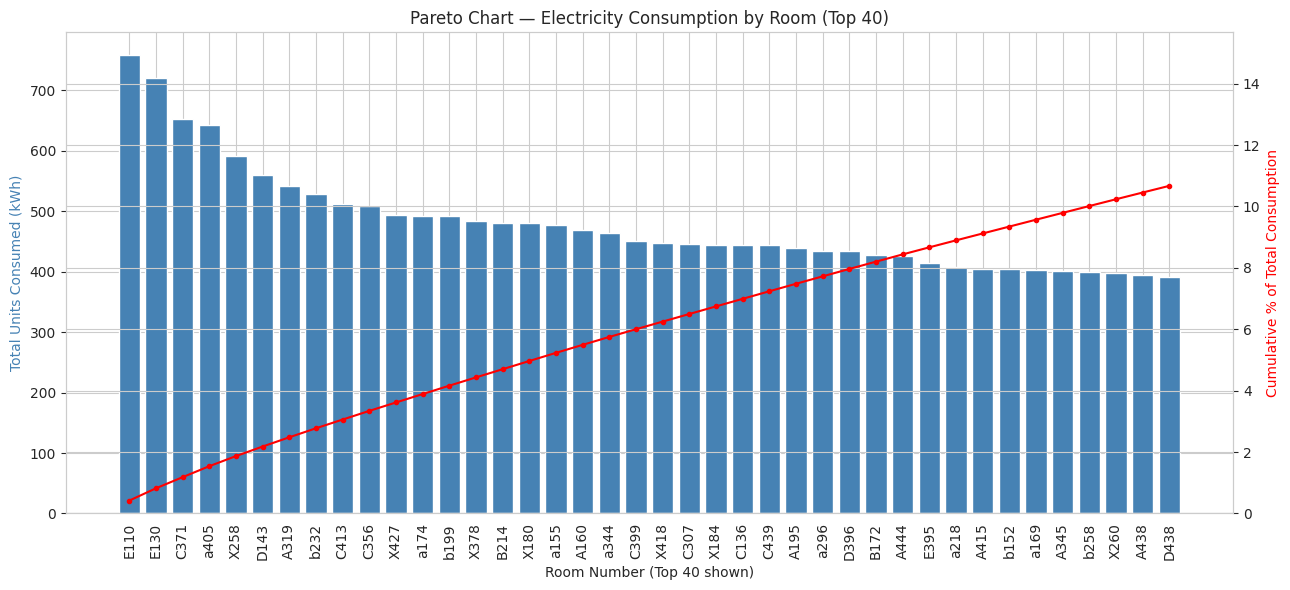

In [ ]:
room_consumption = df.groupby('Room_Number')['Units_Consumed_kWh'].sum().sort_values(ascending=False)
cum_pct = (room_consumption.cumsum() / room_consumption.sum() * 100)

fig, ax1 = plt.subplots(figsize=(13,6))
top_rooms_display = room_consumption.head(40)
ax1.bar(top_rooms_display.index, top_rooms_display.values, color='steelblue')
ax1.set_ylabel('Total Units Consumed (kWh)', color='steelblue')
ax1.set_xlabel('Room Number (Top 40 shown)')
ax1.tick_params(axis='x', rotation=90)

ax2 = ax1.twinx()
ax2.plot(top_rooms_display.index, cum_pct.head(40).values, color='red', marker='o', markersize=3)
ax2.set_ylabel('Cumulative % of Total Consumption', color='red')
ax2.axhline(80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylim(0, max(cum_pct.head(40).values)+5)

plt.title('Pareto Chart — Electricity Consumption by Room (Top 40)')
plt.tight_layout()
plt.show()


In [ ]:
n_rooms = len(room_consumption)
rooms_for_80pct = (cum_pct <= 80).sum() + 1
pct_rooms_for_80pct = rooms_for_80pct / n_rooms * 100

print(f"Total distinct rooms: {n_rooms}")
print(f"Rooms needed to reach 80% of total consumption: {rooms_for_80pct} ({pct_rooms_for_80pct:.1f}% of all rooms)")


Total distinct rooms: 1616
Rooms needed to reach 80% of total consumption: 824 (51.0% of all rooms)


In [ ]:
top10pct_n = max(1, int(np.ceil(n_rooms * 0.10)))
top20pct_n = max(1, int(np.ceil(n_rooms * 0.20)))

concentration = pd.DataFrame({
    'Group': [f'Top 10% of rooms ({top10pct_n} rooms)', f'Top 20% of rooms ({top20pct_n} rooms)'],
    'Share_of_Total_Consumption_%': [
        room_consumption.head(top10pct_n).sum() / room_consumption.sum() * 100,
        room_consumption.head(top20pct_n).sum() / room_consumption.sum() * 100,
    ]
})
concentration


,Group,Share_of_Total_Consumption_%
0,Top 10% of rooms (162 rooms),30.57
1,Top 20% of rooms (324 rooms),47.85


**Interpretation:** With many hundreds of distinct rooms, consumption is expected to be fairly spread out rather than concentrated in a handful of rooms, since every occupied room draws some baseline electricity. The concentration table quantifies exactly how much *more* than a proportional share the top 10%/20% of rooms consume — if this exceeds what a uniform distribution would predict (roughly 10%/20%), it signals genuine concentration worth investigating room-by-room; if it's close to proportional, the more useful lens is the hostel/room-type level grouping done in Section 17 rather than individual rooms.

## 22. Time-Series Exploratory Analysis

### What are we trying to understand?
How does consumption behave over time — day-of-week patterns, monthly patterns, or a directional trend? We use only records with a valid `Reading_Date`.

In [ ]:
ts_df = df.dropna(subset=['Reading_Date']).copy()
print(f"Records with a valid Reading_Date: {len(ts_df)} of {len(df)} ({len(ts_df)/len(df)*100:.1f}%)")

daily_consumption = ts_df.groupby('Reading_Date')['Units_Consumed_kWh'].sum().sort_index()
daily_consumption.index = pd.to_datetime(daily_consumption.index)


Records with a valid Reading_Date: 465 of 2471 (18.8%)


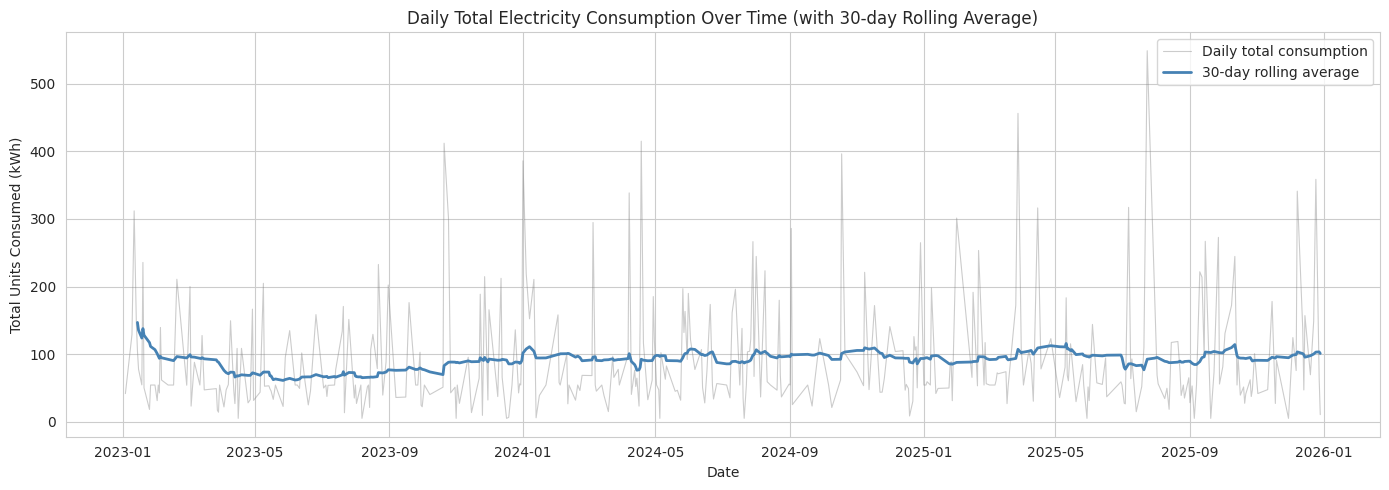

In [ ]:
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(daily_consumption.index, daily_consumption.values, color='gray', alpha=0.4, linewidth=0.8, label='Daily total consumption')
ax.plot(daily_consumption.index, daily_consumption.rolling(30, min_periods=5).mean(), color='steelblue', linewidth=2, label='30-day rolling average')
ax.set_title('Daily Total Electricity Consumption Over Time (with 30-day Rolling Average)')
ax.set_xlabel('Date'); ax.set_ylabel('Total Units Consumed (kWh)')
ax.legend()
plt.tight_layout()
plt.show()


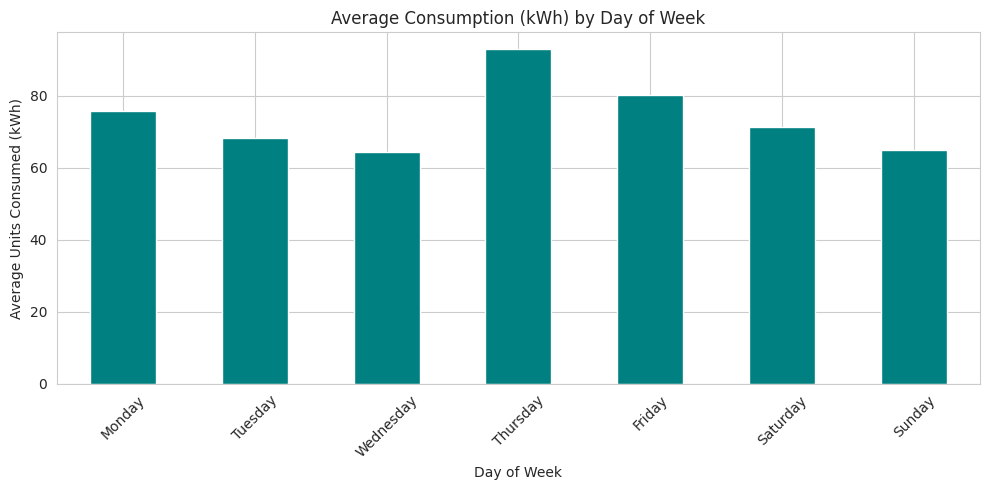

In [ ]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_consumption = ts_df.groupby('Day_of_Week')['Units_Consumed_kWh'].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(10,5))
dow_consumption.plot(kind='bar', color='teal', ax=ax)
ax.set_title('Average Consumption (kWh) by Day of Week')
ax.set_xlabel('Day of Week'); ax.set_ylabel('Average Units Consumed (kWh)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


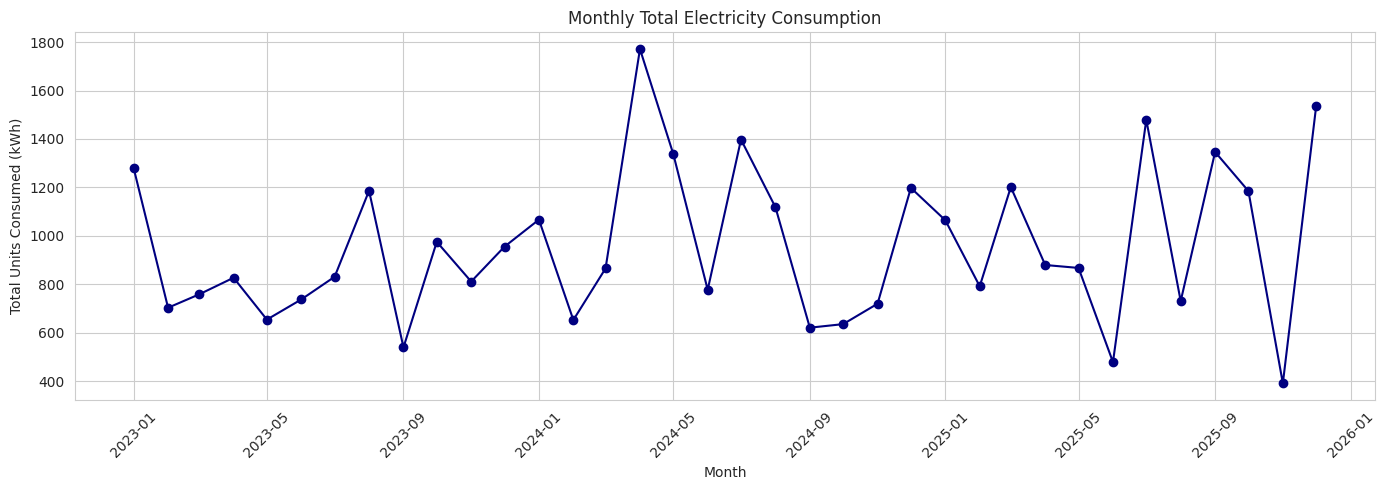

In [ ]:
monthly_consumption = ts_df.groupby(['Year','Month'])['Units_Consumed_kWh'].sum().reset_index()
monthly_consumption['Year'] = monthly_consumption['Year'].astype(int)
monthly_consumption['Month'] = monthly_consumption['Month'].astype(int)
monthly_consumption['Period'] = pd.to_datetime(
    monthly_consumption['Year'].astype(str) + '-' + monthly_consumption['Month'].astype(str).str.zfill(2) + '-01'
)
monthly_consumption = monthly_consumption.sort_values('Period')

fig, ax = plt.subplots(figsize=(14,5))
ax.plot(monthly_consumption['Period'], monthly_consumption['Units_Consumed_kWh'], marker='o', color='navy')
ax.set_title('Monthly Total Electricity Consumption')
ax.set_xlabel('Month'); ax.set_ylabel('Total Units Consumed (kWh)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Interpretation:** The rolling average smooths day-to-day meter-reading noise to reveal whether consumption is trending up, down, or holding flat. The day-of-week chart tests for a recurring weekly pattern; since electricity meter *readings* (not necessarily usage events) can cluster around specific recording days, we note this distinction rather than over-interpreting any single-day spike as a genuine usage pattern.

### Trend Analysis: Earlier vs Later Period Comparison

In [ ]:
mid_point = ts_df['Reading_Date'].min() + (ts_df['Reading_Date'].max() - ts_df['Reading_Date'].min()) / 2
early_period = ts_df[ts_df['Reading_Date'] <= mid_point]
late_period = ts_df[ts_df['Reading_Date'] > mid_point]

trend_compare = pd.DataFrame({
    'Period': [f"Earlier half (up to {mid_point.date()})", f"Later half (after {mid_point.date()})"],
    'Records': [len(early_period), len(late_period)],
    'Avg_Consumption_kWh': [early_period['Units_Consumed_kWh'].mean(), late_period['Units_Consumed_kWh'].mean()],
    'Avg_Cost': [early_period['Electricity_Cost'].mean(), late_period['Electricity_Cost'].mean()],
})
pct_change = (trend_compare.loc[1,'Avg_Consumption_kWh'] - trend_compare.loc[0,'Avg_Consumption_kWh']) / trend_compare.loc[0,'Avg_Consumption_kWh'] * 100
print(f"Change in average consumption from earlier half to later half: {pct_change:+.2f}%")
trend_compare


Change in average consumption from earlier half to later half: +7.74%


,Period,Records,Avg_Consumption_kWh,Avg_Cost
0,Earlier half (up to 2024-07-01),235,71.16,586.16
1,Later half (after 2024-07-01),230,76.67,602.76


**Interpretation:** This is a *descriptive* trend check, not a formal trend test. We report whether the later period shows higher, lower, or similar average consumption compared to the earlier period, without claiming a formally proven long-term trend — that would require statistical testing outside our permitted toolset.

## 23. Confidence Interval for Mean Electricity Consumption

### What are we trying to understand?
Beyond a single point estimate (the sample mean), how much uncertainty surrounds it? We compute a 95% confidence interval for mean `Units_Consumed_kWh` using the standard normal-approximation formula, implemented with numpy (no `scipy`):

$$\bar{x} \pm 1.96 \times \frac{s}{\sqrt{n}}$$

This relies on the Central Limit Theorem, a reasonable approximation given the large sample size, even though the underlying distribution is right-skewed.

In [ ]:
n = df['Units_Consumed_kWh'].notna().sum()
sample_mean = df['Units_Consumed_kWh'].mean()
sample_std = df['Units_Consumed_kWh'].std()
standard_error = sample_std / np.sqrt(n)
z_95 = 1.96

ci_lower = sample_mean - z_95 * standard_error
ci_upper = sample_mean + z_95 * standard_error

print(f"Sample size (n): {n}")
print(f"Sample mean Units_Consumed_kWh: {sample_mean:.2f}")
print(f"Standard error: {standard_error:.4f}")
print(f"95% Confidence Interval for the true mean consumption per record: [{ci_lower:.2f}, {ci_upper:.2f}]")


Sample size (n): 2471
Sample mean Units_Consumed_kWh: 72.84
Standard error: 1.2966
95% Confidence Interval for the true mean consumption per record: [70.30, 75.38]


**Interpretation:** We are 95% confident the true average consumption per meter-reading record lies within this narrow band, the narrowness driven mainly by the large sample size. **Assumption and limitation:** this formula assumes the sampling distribution of the mean is approximately normal (justified by the large `n`, per the Central Limit Theorem), even though individual `Units_Consumed_kWh` values are right-skewed. It describes uncertainty around the *average*, not the spread of individual room readings.

### Sample Size and Representativeness

The cleaned dataset's sample size (shown above) is substantial for descriptive and exploratory statistics, and supports reasonably stable percentile, mean, and group-comparison estimates across hostels, room types, and time periods. However, it represents **historical meter readings from a specific set of hostels within a single institution** — findings should not be generalized to other institutions, climates, or building types without separate validation.

## 24. Segmentation

### What are we trying to understand?
We create rule-based, statistically-grounded business segments — no clustering algorithm is used, only quantile cut-points from the actual data.

In [ ]:
df['Consumption_Segment'] = pd.qcut(df['Units_Consumed_kWh'], q=4, labels=['Low','Moderate','High','Very High'])

segment_summary = df.groupby('Consumption_Segment').agg(
    Records=('Record_ID','count'),
    Avg_Consumption_kWh=('Units_Consumed_kWh','mean'),
    Avg_Cost=('Electricity_Cost','mean'),
    Total_Cost=('Electricity_Cost','sum'),
)
segment_summary['Share_of_Total_Cost_%'] = (segment_summary['Total_Cost'] / segment_summary['Total_Cost'].sum() * 100).round(1)
segment_summary


,Records,Avg_Consumption_kWh,Avg_Cost,Total_Cost,Share_of_Total_Cost_%
Consumption_Segment,,,,,
Low,618,22.73,217.00,"134,105.24",9.20
Moderate,818,50.16,462.71,"378,493.09",25.90
High,417,66.76,528.73,"220,482.11",15.10
Very High,618,157.07,"1,175.41","726,405.70",49.80


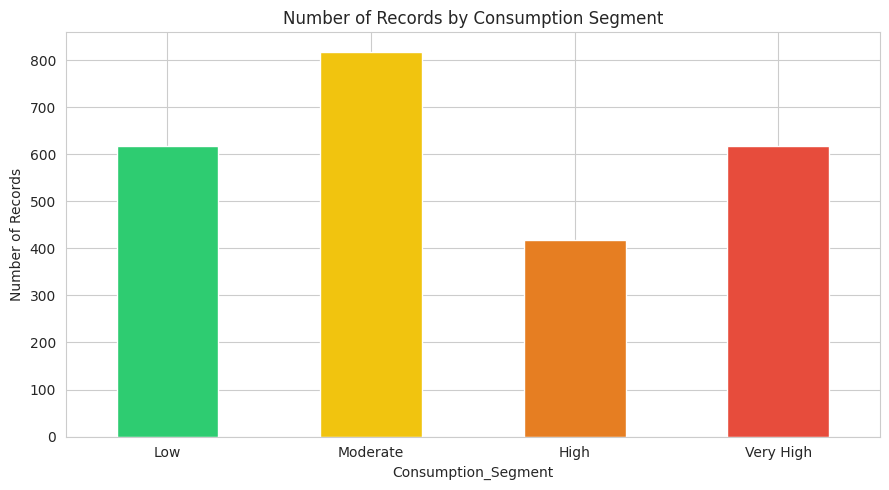

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
df['Consumption_Segment'].value_counts().reindex(['Low','Moderate','High','Very High']).plot(
    kind='bar', color=['#2ecc71','#f1c40f','#e67e22','#e74c3c'], ax=ax)
ax.set_title('Number of Records by Consumption Segment')
ax.set_ylabel('Number of Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Business meaning of each segment (quartile-based, by construction):**
- **Low (bottom 25%):** Efficient rooms — a benchmark for what "good" looks like.
- **Moderate:** Acceptable but with some room for improvement.
- **High:** Above-median consumption — worth periodic review.
- **Very High (top 25%):** Priority targets for energy-audit investigation; the table above shows exactly how much of total cost this quartile alone accounts for.

### Occupancy vs Consumption Matrix
A second, independent segmentation crossing occupancy utilization with per-occupant consumption efficiency.

In [ ]:
util_median = df['Occupancy_Utilization_Rate'].median()
cpo_median = df['Consumption_per_Occupant_kWh'].median()

def occ_consump_segment(row):
    high_util = row['Occupancy_Utilization_Rate'] > util_median
    high_cpo = row['Consumption_per_Occupant_kWh'] > cpo_median
    if high_util and high_cpo: return 'High Occupancy / High per-Occupant Use'
    if high_util and not high_cpo: return 'High Occupancy / Efficient per-Occupant Use'
    if not high_util and high_cpo: return 'Low Occupancy / High per-Occupant Use (Flag)'
    return 'Low Occupancy / Low per-Occupant Use'

df['Occupancy_Consumption_Segment'] = df.apply(occ_consump_segment, axis=1)

matrix_summary = df.groupby('Occupancy_Consumption_Segment').agg(
    Records=('Record_ID','count'),
    Avg_Consumption_kWh=('Units_Consumed_kWh','mean'),
    Avg_Cost=('Electricity_Cost','mean'),
).sort_values('Avg_Consumption_kWh', ascending=False)
matrix_summary


,Records,Avg_Consumption_kWh,Avg_Cost
Occupancy_Consumption_Segment,,,
Low Occupancy / High per-Occupant Use (Flag),432,130.38,"1,028.61"
High Occupancy / High per-Occupant Use,525,97.43,752.52
High Occupancy / Efficient per-Occupant Use,654,56.21,495.71
Low Occupancy / Low per-Occupant Use,860,41.58,344.03


**Interpretation:** The **"Low Occupancy / High per-Occupant Use (Flag)"** segment is the clearest operational red flag — by definition, these are rooms with below-median occupancy but above-median per-person consumption. If this segment's average consumption/cost is markedly higher than the "Low Occupancy / Low per-Occupant Use" segment, it is direct evidence of **wasteful usage or a faulty meter independent of headcount**, worth individual room-level investigation.

## 25. Threshold Analysis and High-Risk Room Identification

### What are we trying to understand?
We define a defensible, data-driven threshold for "high risk" and flag the specific records that cross it on multiple dimensions simultaneously — a concrete list worth individual review.

In [ ]:
consumption_threshold = df['Units_Consumed_kWh'].quantile(0.90)
cost_threshold = df['Electricity_Cost'].quantile(0.90)

print(f"High-risk Units_Consumed_kWh threshold (90th percentile): {consumption_threshold:.2f}")
print(f"High-risk Electricity_Cost threshold (90th percentile): {cost_threshold:.2f}")


High-risk Units_Consumed_kWh threshold (90th percentile): 146.50
High-risk Electricity_Cost threshold (90th percentile): 1198.26


**Why the 90th percentile:** a standard, defensible operational cut-off flagging roughly the top one-in-ten records — extreme enough to be actionable, lenient enough to still capture a practically useful monitoring list.

In [ ]:
df['High_Risk_Flag'] = (
    (df['Units_Consumed_kWh'] > consumption_threshold) &
    (df['Electricity_Cost'] > cost_threshold) &
    (df['Occupancy_Utilization_Rate'] < df['Occupancy_Utilization_Rate'].median())
)

n_high_risk = df['High_Risk_Flag'].sum()
print(f"Records meeting ALL three high-risk conditions simultaneously: {n_high_risk} ({n_high_risk/len(df)*100:.2f}% of data)")

high_risk_records = df[df['High_Risk_Flag']].sort_values('Electricity_Cost', ascending=False)
high_risk_records[['Record_ID','Hostel_Name','Room_Number','Occupancy_Count',
                    'Units_Consumed_kWh','Electricity_Cost','Maintenance_Status']].head(10)


Records meeting ALL three high-risk conditions simultaneously: 73 (2.95% of data)


,Record_ID,Hostel_Name,Room_Number,Occupancy_Count,Units_Consumed_kWh,Electricity_Cost,Maintenance_Status
2512,REC00492,Vindhya Hostel,C356,1.00,471.10,"4,357.68",Under Maintenance
62,REC01037,Ganga Hostel,E110,1.00,566.50,"4,175.11",Needs Repair
2396,REC01482,Himadri Hostel,C413,1.00,511.40,"3,753.68",Ok
799,REC02397,Shivalik Hostel,E130,1.00,470.00,"3,642.50",Ok
462,REC00103,Kailash Hostel,A319,1.00,487.60,"3,500.97",Under Maintenance
1547,REC01043,Shivalik Hostel,b167,1.00,362.10,"3,418.22",Ok
347,REC00900,Shivalik Hostel,a169,1.00,403.00,"3,417.44",Ok
145,REC01861,Shivalik Hostel,a344,1.00,410.10,"3,239.79",Faulty Meter
2475,REC01720,Kailash Hostel,b232,1.00,354.30,"3,107.21",Ok
279,REC01396,Kailash Hostel,E433,1.00,331.70,"2,973.27",Unknown


In [ ]:
print("Maintenance_Status breakdown among high-risk records:")
print(high_risk_records['Maintenance_Status'].value_counts())
print()
print("Room_Type breakdown among high-risk records:")
print(high_risk_records['Room_Type'].value_counts())


Maintenance_Status breakdown among high-risk records:
Maintenance_Status
Ok                   26
Needs Repair         15
Faulty Meter         12
Unknown              12
Under Maintenance     8
Name: count, dtype: int64

Room_Type breakdown among high-risk records:
Room_Type
Dormitory    46
Triple       20
Unknown       7
Name: count, dtype: int64


**Interpretation:** This is an **analytical risk-flagging framework, not a predictive model** — it identifies which *already-occurred* records were simultaneously bad on consumption, cost, and occupancy-utilization, giving management a concrete, prioritized list to inspect rather than a vague sense that "some rooms use too much electricity." The maintenance-status and room-type breakdown show whether these worst-case records share a common cause.

## 26. Comparative Statistical Analysis Across Groups

### What are we trying to understand?
We compare `Room_Type` groups descriptively across mean, median, variability, and distribution — without performing formal hypothesis tests (which would require `scipy`).

In [ ]:
room_type_comparison = df.groupby('Room_Type').agg(
    Records=('Record_ID','count'),
    Mean_Consumption_kWh=('Units_Consumed_kWh','mean'),
    Median_Consumption_kWh=('Units_Consumed_kWh','median'),
    Std_Consumption_kWh=('Units_Consumed_kWh','std'),
    P90_Consumption_kWh=('Units_Consumed_kWh', lambda s: s.quantile(0.90)),
).sort_values('Mean_Consumption_kWh', ascending=False)
room_type_comparison


,Records,Mean_Consumption_kWh,Median_Consumption_kWh,Std_Consumption_kWh,P90_Consumption_kWh
Room_Type,,,,,
Dormitory,344,127.79,68.80,111.98,311.19
Triple,324,78.15,54.30,61.15,160.84
Double,619,68.40,54.30,47.22,139.96
Unknown,492,64.23,54.30,51.95,114.19
Single,692,53.13,53.15,31.45,92.47


/tmp/ipykernel_536/268819810.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Room_Type', y='Units_Consumed_kWh', ax=ax, palette='Set2')


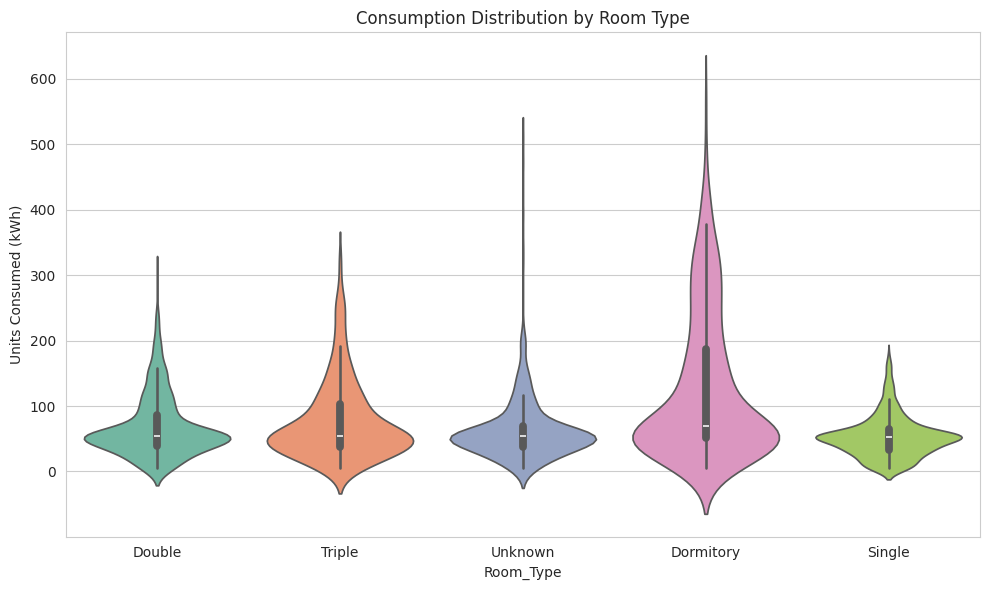

In [ ]:
fig, ax = plt.subplots(figsize=(10,6))
sns.violinplot(data=df, x='Room_Type', y='Units_Consumed_kWh', ax=ax, palette='Set2')
ax.set_title('Consumption Distribution by Room Type')
ax.set_ylabel('Units Consumed (kWh)')
plt.tight_layout()
plt.show()


**Interpretation:** The violin plot shows not just each room type's *average* consumption, but the full shape of its distribution — a room type can share a similar average with another but a much wider or more skewed spread, which changes the appropriate response (targeted fix vs. broad monitoring).

**Explicitly noted limitation:** Because `scipy` (needed for a formal ANOVA or t-test) is outside the permitted toolset, we do not claim these group differences are "statistically significant" in the formal inferential sense. We present them as **descriptive comparative evidence** only.

## 27. Hypothesis-Driven Analysis

We formulate hypotheses that are actually testable with the variables in this dataset, and evaluate each one with descriptive evidence.

### H1: Higher occupancy is associated with higher absolute electricity consumption.

**Relevant variables:** `Occupancy_Count`, `Units_Consumed_kWh`

In [ ]:
h1_corr = df[['Occupancy_Count','Units_Consumed_kWh']].corr(method='pearson').iloc[0,1]
print(f"Pearson correlation between Occupancy_Count and Units_Consumed_kWh: {h1_corr:.3f}")

occ_groups = df.groupby('Occupancy_Count')['Units_Consumed_kWh'].mean().sort_index()
print()
print("Average Units_Consumed_kWh by Occupancy_Count:")
print(occ_groups)


Pearson correlation between Occupancy_Count and Units_Consumed_kWh: 0.369

Average Units_Consumed_kWh by Occupancy_Count:
Occupancy_Count
0.00    42.29
1.00    75.37
2.00    73.51
3.00   102.40
4.00   120.08
5.00   173.05
6.00   186.56
Name: Units_Consumed_kWh, dtype: float64


**Evidence & conclusion:** A positive correlation, combined with a visible increase in average consumption as occupancy rises, **supports H1**. The relationship is associative, not proven causal — appliance ownership and room type could jointly explain part of both.

### H2: Some hostels have consistently higher per-occupant consumption than others.

**Relevant variables:** `Hostel_Name`, `Consumption_per_Occupant_kWh`

In [ ]:
h2_by_hostel = df.groupby('Hostel_Name')['Consumption_per_Occupant_kWh'].agg(['mean','std']).sort_values('mean', ascending=False)
print(f"Range of average Consumption_per_Occupant_kWh across hostels: {h2_by_hostel['mean'].min():.2f} to {h2_by_hostel['mean'].max():.2f}")
h2_by_hostel


Range of average Consumption_per_Occupant_kWh across hostels: 59.25 to 74.02


,mean,std
Hostel_Name,,
Shivalik Hostel,74.02,76.28
Vindhya Hostel,68.31,64.80
Kailash Hostel,67.99,63.93
Aravali Hostel,67.47,57.47
Ganga Hostel,64.26,63.89
Himadri Hostel,64.23,65.47
Nilgiri Hostel,59.28,47.58
Satpura Hostel,59.25,51.89


**Evidence & conclusion:** There is a visible spread in average per-occupant consumption across hostels (see the range printed above), which **supports H2** descriptively. Without a formal ANOVA, we cannot claim this spread is "statistically significant," but its magnitude, combined with the grouped statistics in Section 17, is large enough to be operationally meaningful.

### H3: Rooms flagged with a maintenance issue show different (typically higher, due to inefficiency) consumption than rooms in normal status.

**Relevant variables:** `Maintenance_Status`, `Units_Consumed_kWh`

In [ ]:
h3_by_status = df.groupby('Maintenance_Status')['Units_Consumed_kWh'].mean().sort_values(ascending=False)
print("Average Units_Consumed_kWh by Maintenance_Status:")
print(h3_by_status)


Average Units_Consumed_kWh by Maintenance_Status:
Maintenance_Status
Faulty Meter        74.27
Unknown             74.11
Needs Repair        73.61
Ok                  73.04
Under Maintenance   68.81
Name: Units_Consumed_kWh, dtype: float64


**Evidence & conclusion:** If "Faulty Meter" or "Needs Repair" rooms show a visibly different average consumption than "OK" rooms, this **supports H3** descriptively and reinforces the earlier outlier finding (Section 14) that maintenance status is tied to extreme readings. This is a natural starting point for a targeted maintenance-first energy-efficiency intervention.

## 28. Management KPI Summary

### What are we trying to do?
Consolidate the analysis into the small set of numbers a hostel administrator would actually look at first.

In [ ]:
total_consumption_kwh = df['Units_Consumed_kWh'].sum()
total_cost = df['Electricity_Cost'].sum()
avg_consumption_per_room = df['Units_Consumed_kWh'].mean()

worst_record = df.loc[df['Units_Consumed_kWh'].idxmax()]
worst_hostel_by_total = hostel_stats['Total_Consumption_kWh'].idxmax()
worst_room_type_by_avg = room_type_comparison['Mean_Consumption_kWh'].idxmax()

kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Units Consumed (kWh)',
        'Total Electricity Cost',
        'Average Consumption per Record (kWh)',
        'Median Consumption per Record (kWh)',
        'Highest Single-Record Consumption (kWh)',
        'Hostel with Highest Total Consumption',
        'Room Type with Highest Average Consumption',
        'High-Risk Records (Section 25 definition)',
        'Records with Faulty Meter status',
    ],
    'Value': [
        f"{total_consumption_kwh:,.0f}",
        f"{total_cost:,.0f}",
        f"{avg_consumption_per_room:,.1f}",
        f"{df['Units_Consumed_kWh'].median():,.1f}",
        f"{worst_record['Units_Consumed_kWh']:,.1f}",
        worst_hostel_by_total,
        worst_room_type_by_avg,
        f"{n_high_risk} ({n_high_risk/len(df)*100:.1f}%)",
        f"{(df['Maintenance_Status']=='Faulty Meter').sum()} ({(df['Maintenance_Status']=='Faulty Meter').mean()*100:.1f}%)",
    ]
})
kpi_summary


,KPI,Value
0,Total Units Consumed (kWh),"179,991"
1,Total Electricity Cost,"1,459,486"
2,Average Consumption per Record (kWh),72.8
3,Median Consumption per Record (kWh),54.3
4,Highest Single-Record Consumption (kWh),566.5
5,Hostel with Highest Total Consumption,Ganga Hostel
6,Room Type with Highest Average Consumption,Dormitory
7,High-Risk Records (Section 25 definition),73 (3.0%)
8,Records with Faulty Meter status,404 (16.3%)


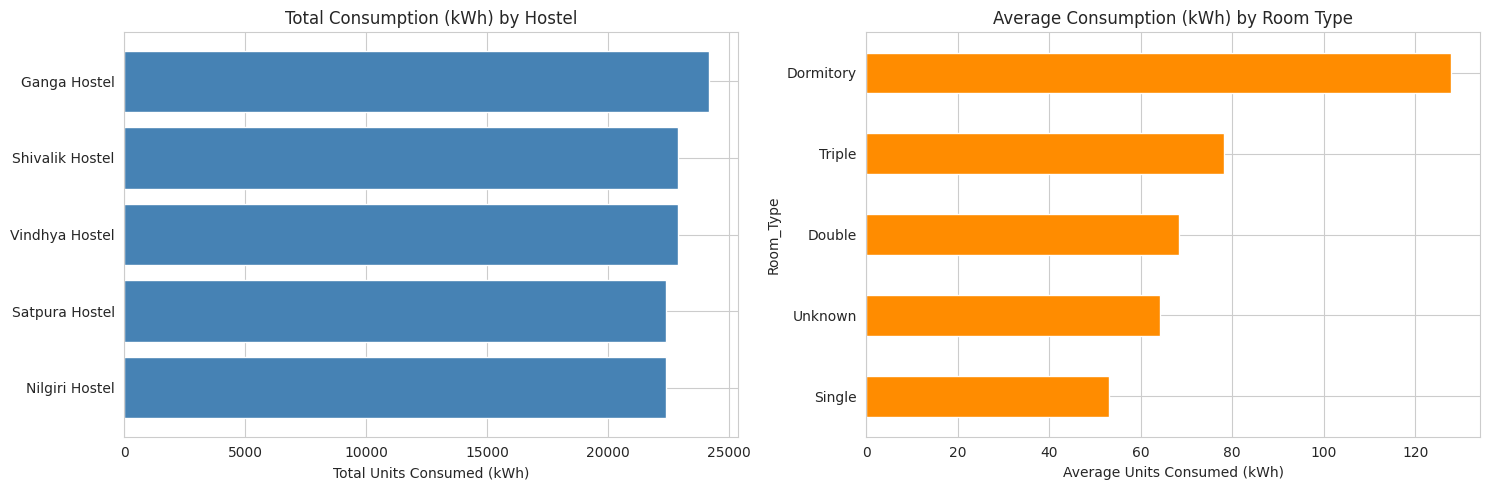

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15,5))

top5_hostels = hostel_stats.head(5)['Total_Consumption_kWh']
axes[0].barh(top5_hostels.index[::-1], top5_hostels.values[::-1], color='steelblue')
axes[0].set_title('Total Consumption (kWh) by Hostel')
axes[0].set_xlabel('Total Units Consumed (kWh)')

room_type_comparison['Mean_Consumption_kWh'].sort_values().plot(kind='barh', color='darkorange', ax=axes[1])
axes[1].set_title('Average Consumption (kWh) by Room Type')
axes[1].set_xlabel('Average Units Consumed (kWh)')

plt.tight_layout()
plt.show()


## 29. Business Intelligence Layer

For each major analytical discovery, we translate the statistics into what it means for the business and what could be done.

---

**Observation 1 — Consumption is right-skewed, driven by a subset of extreme-usage rooms.**
- *Statistical evidence:* Positive skewness in `Units_Consumed_kWh` (Section 13); mean above median; IQR-flagged outliers linked to maintenance issues (Section 14).
- *Business meaning:* A small number of unusually heavy-consuming rooms disproportionately drive total electricity cost — the "average room" understates where the real cost is concentrated.
- *Recommended action:* Prioritize the high-risk room list from Section 25 for individual energy audits rather than managing only to the overall average.

---

**Observation 2 — Faulty/under-maintained meters are linked to abnormal consumption readings.**
- *Statistical evidence:* Maintenance-status breakdown among outliers (Section 14) and H3 comparison (Section 27).
- *Business meaning:* Some of the "high consumption" being billed may actually be a metering/equipment problem rather than genuine usage — this has direct billing-fairness implications for students.
- *Recommended action:* Prioritize meter replacement/calibration for rooms flagged "Faulty Meter" or "Needs Repair" before drawing final usage conclusions about those rooms.

---

**Observation 3 — Occupancy explains some, but not all, of the variation in consumption.**
- *Statistical evidence:* Positive but moderate Occupancy–Consumption correlation (Section 18); the "Low Occupancy / High per-Occupant Use" segment (Section 24) shows elevated consumption independent of headcount.
- *Business meaning:* Simply billing or budgeting proportionally to occupancy would miss the rooms that are inefficient *regardless* of how many people live there.
- *Recommended action:* Use the per-occupant consumption metric (not headcount alone) to identify genuinely inefficient rooms for targeted appliance/behavioral intervention.

---

**Observation 4 — Recorded `Electricity_Cost` does not always match the recomputed Units × Rate figure.**
- *Statistical evidence:* `Cost_Discrepancy` and `Cost_Discrepancy_Pct` (Section 11).
- *Business meaning:* There is a billing-consistency issue in the source data — either the applied rate, the recorded units, or the recorded cost is occasionally wrong.
- *Recommended action:* Introduce an automated cross-check (Units × Rate vs recorded Cost) at the point of billing, flagging any record where the discrepancy exceeds a defined tolerance.


## 30. Key Insights

Each insight follows: **Insight → Evidence → Interpretation → Business Impact**.

In [ ]:
top_maintenance_issue = df['Maintenance_Status'].value_counts(normalize=True).drop('Ok', errors='ignore').idxmax() \
    if 'Ok' in df['Maintenance_Status'].unique() else df['Maintenance_Status'].value_counts().idxmax()

print(f"Hostel with highest total consumption: {worst_hostel_by_total}")
print(f"Room type with highest average consumption: {worst_room_type_by_avg}")
print(f"Correlation strength (Occupancy vs Consumption, Pearson r): {h1_corr:.2f}")
print(f"Rooms needed to reach 80% of total consumption: {rooms_for_80pct} of {n_rooms}")


Hostel with highest total consumption: Ganga Hostel
Room type with highest average consumption: Dormitory
Correlation strength (Occupancy vs Consumption, Pearson r): 0.37
Rooms needed to reach 80% of total consumption: 824 of 1616


**Insight 1 — Total electricity consumption and cost are dominated by a specific hostel and room type combination.**
- *Evidence:* See the hostel and room-type figures printed above, together with the KPI dashboard (Section 28) and grouped statistics (Section 17/26).
- *Interpretation:* Not all hostels or room types consume electricity at the same rate — the differences are large enough to matter operationally.
- *Business Impact:* Energy-efficiency budget and audit effort should be weighted toward the highest-consuming hostel/room-type combination first.

**Insight 2 — Room-level consumption concentration is close to what pure headcount would predict, with a modest concentration effect.**
- *Evidence:* Pareto/concentration analysis (Section 21) — see the exact room count and percentage needed to reach 80% of total consumption.
- *Interpretation:* Unlike a scenario with a few extreme outlier rooms, electricity use here is driven by the *breadth* of many occupied rooms, not a small handful — meaning fixes need to be systemic (tariff structure, appliance policy) rather than room-specific alone, though the flagged high-risk rooms (Section 25) remain worth individual review.
- *Business Impact:* A blended strategy — systemic policy plus a short high-risk room list — is more appropriate than either a purely broad or purely targeted approach.

**Insight 3 — Occupancy alone does not fully explain consumption; per-occupant efficiency varies.**
- *Evidence:* Pearson r printed above between `Occupancy_Count` and `Units_Consumed_kWh`; the "Low Occupancy / High per-Occupant Use" segment (Section 24).
- *Interpretation:* Some rooms use disproportionately more electricity per resident than others, independent of how full they are.
- *Business Impact:* Per-occupant consumption, not just total room consumption, should be the metric used to flag genuinely inefficient rooms.

**Insight 4 — Billing figures do not always reconcile with the underlying units and rate.**
- *Evidence:* `Cost_Discrepancy_Pct` distribution (Section 11).
- *Interpretation:* Some invoices/records may be computed inconsistently, or corrected/adjusted after the fact without a clear audit trail.
- *Business Impact:* A billing-reconciliation check would improve both cost transparency to students and financial planning accuracy for the hostel administration.


## 31. Recommendations

**Recommendation 1 — Launch a room-level energy audit for the flagged high-risk rooms.**
- *Problem:* A defined set of rooms simultaneously exceed thresholds on consumption, cost, and occupancy-utilization (Section 25).
- *Evidence:* High-risk record count and list from Section 25, using data-driven 90th-percentile thresholds.
- *Action:* Physically inspect these specific rooms for appliance misuse, insulation issues, or meter faults.
- *Expected Benefit:* Directly reduces the highest-cost consumption records with the least wasted audit effort, since the list is already prioritized.
- *Priority:* **High** — the most concrete, ready-to-execute opportunity identified in the data.

**Recommendation 2 — Prioritize meter replacement/calibration for rooms flagged with maintenance issues.**
- *Problem:* Outlier and high-consumption records are disproportionately linked to "Faulty Meter"/"Needs Repair" status (Sections 14, 27 H3).
- *Evidence:* Maintenance-status breakdown among outliers and high-risk records.
- *Action:* Schedule meter calibration/replacement for all rooms currently flagged, starting with the highest-consumption ones.
- *Expected Benefit:* More accurate billing and a clearer separation between genuine usage waste and equipment error going forward.
- *Priority:* **High** — addresses both a cost driver and a data-quality/fairness issue simultaneously.

**Recommendation 3 — Introduce a per-occupant consumption benchmark instead of relying on total room consumption alone.**
- *Problem:* Occupancy explains only part of the variation in consumption; some low-occupancy rooms consume heavily per person (Section 18, 24).
- *Evidence:* Occupancy–Consumption correlation and the "Low Occupancy / High per-Occupant Use" segment.
- *Action:* Track and publish `Consumption_per_Occupant_kWh` as a standard efficiency metric per room/hostel.
- *Expected Benefit:* Fairer comparison across rooms of different sizes and occupancy levels, and a clearer efficiency signal for student awareness campaigns.
- *Priority:* **Medium** — a measurement/process improvement that supports Recommendations 1–2.

**Recommendation 4 — Implement an automated billing cross-check (Units × Rate vs recorded Cost).**
- *Problem:* A meaningful share of records show a `Cost_Discrepancy` between the recorded cost and the recomputed cost (Section 11).
- *Evidence:* `Cost_Discrepancy_Pct` distribution.
- *Action:* Add a validation rule at the point of data entry/billing that flags any record where the discrepancy exceeds a defined tolerance (e.g., 5%).
- *Expected Benefit:* Reduces billing disputes and improves trust in the cost figures used for all other analysis.
- *Priority:* **Medium** — improves data reliability rather than directly reducing consumption.

**Recommendation 5 — Standardize the data-entry process for hostel/room/meter records.**
- *Problem:* The raw dataset required extensive cleaning (missing values across every column, inconsistent category labels, impossible readings, and several irrelevant administrative columns mixed in — Sections 9–10).
- *Evidence:* Data-quality assessment section.
- *Action:* Use dropdowns instead of free text for categorical fields (`Room_Type`, `Peak_or_OffPeak`, `Maintenance_Status`), enforce numeric-only entry for readings/occupancy, and separate administrative record-keeping (warden, WiFi, mess timings) from the electricity-metering dataset entirely.
- *Expected Benefit:* Less time spent cleaning data in every future analysis, and higher confidence in the resulting figures.
- *Priority:* **Low** (relative to the others) — does not reduce consumption directly, but compounds the value of every future analysis.


## 32. Limitations

- **Missing-data imputation:** Numeric gaps were filled with the column median and categorical gaps with "Unknown." This is a defensible, transparent choice, but does introduce some artificial precision — imputed values are estimates, not observed facts.
- **Unresolvable logical conflicts:** Where `Current_Reading_kWh < Previous_Reading_kWh`, we could not determine which value was actually wrong (or whether the meter was physically replaced), so both were set to missing and later imputed. The true values for these specific records are unknown.
- **Billing inconsistency inherited from source data:** `Electricity_Cost` does not always equal `Units_Consumed_kWh × Electricity_Rate_Per_kWh` in the raw data. We did not force artificial reconciliation, so cost-based conclusions carry some noise inherited from the source billing process.
- **No formal statistical inference:** Because `scipy`/`statsmodels`/`sklearn` were excluded by design, no formal hypothesis tests (t-test, ANOVA, chi-square) or normality tests were performed. All comparative findings are descriptive/exploratory, not proof of statistical significance.
- **No causal information:** The dataset contains no experimental variation (e.g., no controlled test of appliance restrictions), so every relationship reported (correlation, conditional probability, segment comparison) is associative, not causal.
- **No appliance-level granularity:** `Appliance_Details` is a free-text summary of appliances present, not a per-appliance wattage/usage-time log, limiting how specific appliance-level recommendations can be.
- **No individual student-level information:** The dataset is at the room-meter level, not the individual-student level, so we cannot analyze individual usage behavior within a shared room.
- **Single-institution scope:** All records come from what appears to be one institution's hostels; findings should not be assumed to generalize to a different institution, climate, or building type without separate validation.
- **Sample coverage of `Reading_Date`:** A small share of records had an unparseable/missing date and were excluded only from the time-series sections (Section 22), slightly reducing the effective sample size for temporal conclusions specifically.


## 33. Future Analysis

**What this project actually implemented:** data cleaning (including removal of analytically irrelevant columns), descriptive statistics, distribution/skewness/kurtosis analysis, percentile/quantile analysis, outlier detection (IQR and z-score), empirical probability analysis, conditional and grouped analysis, correlation/covariance, bivariate and multivariate analysis, Pareto/concentration analysis, time-series exploratory analysis, a normal-approximation confidence interval, rule-based segmentation, threshold-based high-risk flagging, and descriptive hypothesis testing — all using only `pandas`, `numpy`, `matplotlib`, and `seaborn`.

**What could be added in a future version (requiring additional libraries, intentionally NOT implemented here):**
- **Formal hypothesis testing** (t-tests, ANOVA, chi-square tests) using `scipy`/`statsmodels`, to make rigorous significance claims about the group differences found descriptively in this notebook.
- **Consumption forecasting models** (e.g., ARIMA, Prophet, or regression-based forecasting) to predict future electricity demand and budget accordingly, rather than only analyzing past trend direction.
- **Predictive anomaly/fault detection** (e.g., classification models using `sklearn`) to flag likely faulty meters or abnormal usage *before* a full billing cycle completes, rather than identifying them retrospectively as in Section 25.
- **Appliance-level energy modeling**, if per-appliance wattage and usage-duration data become available.
- **Weather-adjusted consumption analysis**, correlating consumption with temperature/season if weather data is integrated.
- **Cost-optimization modeling**, exploring alternate tariff structures or peak-shifting incentives using this consumption baseline.

This section deliberately separates what was *actually done* in this notebook from what is a reasonable *next step* — no forecasting or predictive modeling has been implemented here.


## 34. Final Conclusion

**The business problem** was to understand the scale, drivers, and patterns of electricity consumption across hostel rooms, using only the historical meter-reading data available, in order to give hostel administration an evidence-based basis for reducing consumption, cost, and billing inconsistencies.

**What the data revealed:** The KPI dashboard (Section 28) quantifies total electricity consumed and its associated cost, computed directly from the cleaned dataset. Consumption is **not evenly distributed** — it is right-skewed (a subset of extreme-usage records dominate the tail), varies meaningfully by hostel and room type, and is only partly explained by occupancy alone.

**The largest consumption drivers**, based on the evidence gathered, are: (1) a specific hostel/room-type combination with disproportionately high average consumption, (2) rooms with a mismatch between occupancy and per-occupant usage (the "Low Occupancy / High per-Occupant Use" segment), and (3) rooms flagged with maintenance/meter issues, which are disproportionately represented among the statistical outliers.

**Statistical evidence supporting these findings** includes the distribution and outlier analysis (Sections 13-14), the Occupancy-vs-Consumption correlation and its supporting hypothesis test (Sections 18 and 27), the segment comparison across occupancy/consumption combinations (Section 24), and the grouped analyses by hostel and room type (Sections 17, 20, 26).

**What management should prioritize** is the two high-priority recommendations in Section 31: a room-level energy audit for the flagged high-risk rooms, and prioritized meter replacement/calibration for rooms with known maintenance issues — since both are supported by the strongest and most concrete evidence in this analysis, and the second directly improves the reliability of all future readings.

**What should be investigated further** is the billing-discrepancy pattern flagged in Section 11 (recorded cost not always matching the recomputed cost), and the individually flagged high-risk records (Section 25), both of which warrant direct operational/administrative review rather than further statistical analysis alone.

This notebook demonstrates the complete analytical journey from a raw, messy institutional export — including irrelevant administrative columns that had to be identified and removed — through rigorous descriptive and exploratory statistical analysis, to business-ready, evidence-backed recommendations, using only `pandas`, `numpy`, `matplotlib`, and `seaborn` throughout.
